# 06 Academic Figures and Tables


In [2]:
from __future__ import annotations

import html
import importlib.util
import json
import math
import os
import re
import time
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd

CODE_DIR = Path('/Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection')
PROJECT_ROOT = Path('/Users/tiencains/Documents/dissertation/dissertation process')
DATA_DIR = PROJECT_ROOT / 'data choosing list' / 'Phishing Email Curated Datasets'
CEAS_PATH = DATA_DIR / 'CEAS_08.csv'
ENRON_PATH = DATA_DIR / 'Enron.csv'
API_KEY_FILE = CODE_DIR / 'openai_api_key.txt'

OUTPUT_DIR = CODE_DIR / 'output'
DATA_OUTPUT_DIR = OUTPUT_DIR / 'data'
STATS_OUTPUT_DIR = OUTPUT_DIR / 'statistics'
FIGURE_OUTPUT_DIR = OUTPUT_DIR / 'figures'
MODEL_OUTPUT_DIR = OUTPUT_DIR / 'models'
EMBEDDING_OUTPUT_DIR = OUTPUT_DIR / 'embeddings'
ERROR_OUTPUT_DIR = OUTPUT_DIR / 'error_analysis'
REPORT_OUTPUT_DIR = OUTPUT_DIR / 'reports'

RANDOM_SEED = 42
EXPECTED_RAW_ROWS = 68921
EXPECTED_RAW_LABEL_COUNTS = {1: 35818, 0: 33103}
SCALABILITY_EMAIL_COUNTS = [10_000, 100_000, 1_000_000]

# I keep pricing assumptions here so I can update the cost section before final writing.
EMBEDDING_PRICES_USD_PER_1M_TOKENS = {
    'text-embedding-3-small': 0.02,
    'text-embedding-3-large': 0.13,
}

API_KEY_EMPTY_MARKERS = {
    '',
    'PENGFEI_OPENAI_KEY_FOR_EMBEDDINGS',
}

os.chdir(CODE_DIR)
os.environ.setdefault('MPLCONFIGDIR', str(OUTPUT_DIR / 'matplotlib_cache'))


def ensure_output_dirs() -> None:
    for path in [
        OUTPUT_DIR,
        DATA_OUTPUT_DIR,
        STATS_OUTPUT_DIR,
        FIGURE_OUTPUT_DIR,
        MODEL_OUTPUT_DIR,
        EMBEDDING_OUTPUT_DIR,
        ERROR_OUTPUT_DIR,
        REPORT_OUTPUT_DIR,
    ]:
        path.mkdir(parents=True, exist_ok=True)


def check_packages(packages: Iterable[str]) -> list[str]:
    return [package for package in packages if importlib.util.find_spec(package) is None]


def require_packages(packages: Iterable[str]) -> None:
    missing = check_packages(packages)
    if missing:
        raise RuntimeError(
            'Missing packages: ' + ', '.join(missing) +
            '. In PyCharm, select the project .venv interpreter, or install these packages in that interpreter.'
        )


def now_seconds() -> float:
    return time.perf_counter()


def elapsed(start: float) -> float:
    return round(time.perf_counter() - start, 4)


def save_json(data: dict[str, Any], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding='utf-8')


def load_openai_api_key() -> str | None:
    env_key = os.getenv('OPENAI_API_KEY', '').strip()
    if env_key and env_key not in API_KEY_EMPTY_MARKERS:
        return env_key
    if not API_KEY_FILE.exists():
        return None
    for raw_line in API_KEY_FILE.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('OPENAI_API_KEY='):
            line = line.split('=', 1)[1].strip()
        line = line.strip().strip('"').strip("'")
        if line and line not in API_KEY_EMPTY_MARKERS:
            os.environ['OPENAI_API_KEY'] = line
            return line
    return None


def standardize_email_frame(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    df = df.copy()
    df['source_dataset'] = source_name
    for col in ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']:
        if col not in df.columns:
            df[col] = pd.NA
    df['subject'] = df['subject'].fillna('').astype(str)
    df['body'] = df['body'].fillna('').astype(str)
    df['text'] = (
        df['subject'].str.cat(df['body'], sep=' ')
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')
    return df[['source_dataset', 'sender', 'receiver', 'date', 'subject', 'body', 'text', 'label', 'urls']]


URL_RE = re.compile(r'(https?://\S+|www\.\S+)', flags=re.IGNORECASE)
EMAIL_RE = re.compile(r'\b[\w.\-+%]+@[\w.\-]+\.[A-Za-z]{2,}\b')
HTML_TAG_RE = re.compile(r'<[^>]+>')
CONTROL_RE = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]')
NUMBER_RE = re.compile(r'\b\d+(?:[.,:/-]\d+)*\b')
MULTISPACE_RE = re.compile(r'\s+')


def strip_html(text: str) -> str:
    text = html.unescape(str(text))
    return HTML_TAG_RE.sub(' ', text)


def clean_text_level1(text: str) -> str:
    text = strip_html(text)
    text = CONTROL_RE.sub(' ', text)
    text = URL_RE.sub(' URLTOKEN ', text)
    text = EMAIL_RE.sub(' EMAILTOKEN ', text)
    text = NUMBER_RE.sub(' NUMBERTOKEN ', text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9_<>@\s\-']", ' ', text)
    return MULTISPACE_RE.sub(' ', text).strip()


def make_dedup_key(text: pd.Series) -> pd.Series:
    return (
        text.fillna('').astype(str).map(strip_html).str.lower()
        .str.replace(r'\s+', ' ', regex=True).str.strip()
    )


def simple_tokenize(text: str) -> list[str]:
    return re.findall(r"[a-z0-9_<>@\-']+", str(text).lower())


OBFUSCATION_MAP = {
    'password': 'p a s s w 0 r d',
    'account': 'acc0unt',
    'verify': 'ver!fy',
    'login': 'log-in',
    'click': 'cl1ck',
    'urgent': 'urg3nt',
    'security': 'sec urity',
    'bank': 'b@nk',
    'payment': 'pay ment',
    'update': 'up date',
}


def perturb_text_level2(text: str) -> str:
    text = strip_html(text)
    text = URL_RE.sub(' hxxps://example[.]com/secure-login ', text)
    text = EMAIL_RE.sub(' support [at] example [dot] com ', text)
    pattern = re.compile(r'\b(' + '|'.join(map(re.escape, OBFUSCATION_MAP)) + r')\b', re.I)

    def replace_word(match: re.Match[str]) -> str:
        word = match.group(0)
        replacement = OBFUSCATION_MAP.get(word.lower(), word)
        return replacement.upper() if word.isupper() else replacement

    text = pattern.sub(replace_word, text)
    text = re.sub(r'([!?.,;:])', r' \1 ', text)
    return re.sub(r'\s+', ' ', text).strip()


def add_text_length_columns(df: pd.DataFrame, column: str = 'text') -> pd.DataFrame:
    df = df.copy()
    df['char_count'] = df[column].fillna('').astype(str).str.len()
    df['word_count'] = df[column].fillna('').astype(str).str.split().str.len()
    return df


def validate_raw_counts(df: pd.DataFrame) -> None:
    actual_rows = len(df)
    actual_counts = {int(k): int(v) for k, v in df['label'].value_counts(dropna=False).to_dict().items() if pd.notna(k)}
    if actual_rows != EXPECTED_RAW_ROWS:
        raise AssertionError(f'Unexpected raw row count: {actual_rows}; expected {EXPECTED_RAW_ROWS}')
    if actual_counts != EXPECTED_RAW_LABEL_COUNTS:
        raise AssertionError(f'Unexpected raw label counts: {actual_counts}; expected {EXPECTED_RAW_LABEL_COUNTS}')


def estimate_tokens_from_text(text: str) -> int:
    # I use this lightweight estimate so the cost comparison stays reproducible offline.
    text = str(text)
    return max(1, math.ceil(len(text) / 4))


def estimate_tokens_for_series(texts: pd.Series) -> int:
    return int(texts.fillna('').astype(str).map(estimate_tokens_from_text).sum())


def estimate_embedding_cost_usd(model_name: str, total_tokens: int) -> float:
    price = EMBEDDING_PRICES_USD_PER_1M_TOKENS.get(model_name, 0.0)
    return round((total_tokens / 1_000_000) * price, 6)


def projected_seconds(seconds_per_email: float, email_count: int) -> float:
    return round(seconds_per_email * email_count, 4)


def projected_cost(cost_per_email: float, email_count: int) -> float:
    return round(cost_per_email * email_count, 6)


def add_cost_columns(row: dict[str, Any], row_count: int, token_cost_usd: float = 0.0, total_tokens: int = 0) -> dict[str, Any]:
    inference_seconds = float(row.get('inference_seconds', 0.0) or 0.0)
    feature_seconds = float(row.get('feature_generation_seconds', row.get('embedding_seconds', row.get('vectorizer_seconds', 0.0))) or 0.0)
    train_seconds = float(row.get('train_seconds', 0.0) or 0.0)
    total_runtime = feature_seconds + train_seconds + inference_seconds
    seconds_per_email = inference_seconds / row_count if row_count else 0.0
    cost_per_email = token_cost_usd / row_count if row_count else 0.0
    row.update({
        'total_runtime_seconds': round(total_runtime, 4),
        'inference_seconds_per_email': round(seconds_per_email, 8),
        'throughput_emails_per_second': round(row_count / inference_seconds, 4) if inference_seconds > 0 else np.nan,
        'estimated_input_tokens': int(total_tokens),
        'estimated_token_cost_usd': round(token_cost_usd, 6),
        'estimated_cost_per_email_usd': round(cost_per_email, 10),
        'projected_seconds_10k': projected_seconds(seconds_per_email, 10_000),
        'projected_seconds_100k': projected_seconds(seconds_per_email, 100_000),
        'projected_seconds_1m': projected_seconds(seconds_per_email, 1_000_000),
        'projected_cost_10k_usd': projected_cost(cost_per_email, 10_000),
        'projected_cost_100k_usd': projected_cost(cost_per_email, 100_000),
        'projected_cost_1m_usd': projected_cost(cost_per_email, 1_000_000),
    })
    return row


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray, scores: np.ndarray | None) -> dict[str, Any]:
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'false_positive_rate': fp / (fp + tn) if (fp + tn) else 0.0,
        'false_negative_rate': fn / (fn + tp) if (fn + tp) else 0.0,
    }
    if scores is not None and len(np.unique(y_true)) == 2:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, scores)
        except ValueError:
            metrics['roc_auc'] = np.nan
    else:
        metrics['roc_auc'] = np.nan
    return metrics


def model_scores(model: Any, x: Any) -> np.ndarray | None:
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(x)
        if proba.ndim == 2 and proba.shape[1] > 1:
            return proba[:, 1]
    if hasattr(model, 'decision_function'):
        return np.asarray(model.decision_function(x))
    return None


def evaluate_model(model: Any, x: Any, y: np.ndarray) -> tuple[dict[str, Any], np.ndarray, np.ndarray | None]:
    start = now_seconds()
    y_pred = model.predict(x)
    inference_seconds = elapsed(start)
    scores = model_scores(model, x)
    metrics = classification_metrics(y, y_pred, scores)
    metrics['inference_seconds'] = inference_seconds
    return metrics, np.asarray(y_pred), scores


def export_error_cases(df: pd.DataFrame, y_pred: np.ndarray, scores: np.ndarray | None, model_id: str) -> tuple[Path, Path]:
    ERROR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    errors = df.copy()
    errors['predicted_label'] = y_pred
    errors['prediction_score'] = scores if scores is not None else np.nan
    cols = [c for c in ['source_dataset', 'subject', 'text', 'text_clean', 'label', 'predicted_label', 'prediction_score'] if c in errors.columns]
    false_negatives = errors[(errors['label'] == 1) & (errors['predicted_label'] == 0)]
    false_positives = errors[(errors['label'] == 0) & (errors['predicted_label'] == 1)]
    fn_path = ERROR_OUTPUT_DIR / f'{model_id}_false_negatives.csv'
    fp_path = ERROR_OUTPUT_DIR / f'{model_id}_false_positives.csv'
    false_negatives[cols].to_csv(fn_path, index=False)
    false_positives[cols].to_csv(fp_path, index=False)
    return fn_path, fp_path


ACADEMIC_BLUE = '#0072B2'
ACADEMIC_VERMILLION = '#D55E00'
ACADEMIC_GREEN = '#009E73'
ACADEMIC_PURPLE = '#CC79A7'
ACADEMIC_ORANGE = '#E69F00'
ACADEMIC_SKY_BLUE = '#56B4E9'
ACADEMIC_YELLOW = '#F0E442'
ACADEMIC_BLACK = '#222222'
ACADEMIC_GRAY = '#666666'
ACADEMIC_LIGHT_GRAY = '#D9D9D9'
ACADEMIC_PALETTE = [
    ACADEMIC_BLUE,
    ACADEMIC_VERMILLION,
    ACADEMIC_GREEN,
    ACADEMIC_PURPLE,
    ACADEMIC_ORANGE,
    ACADEMIC_SKY_BLUE,
    ACADEMIC_YELLOW,
    ACADEMIC_BLACK,
]
CLASS_COLORS = {0: ACADEMIC_BLUE, 1: ACADEMIC_VERMILLION}


def setup_academic_plotting() -> Any:
    import matplotlib
    matplotlib.use('Agg')
    from cycler import cycler
    from matplotlib import pyplot as plt

    plt.rcParams.update({
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'legend.fontsize': 8.5,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': ACADEMIC_BLACK,
        'axes.labelcolor': ACADEMIC_BLACK,
        'xtick.color': ACADEMIC_BLACK,
        'ytick.color': ACADEMIC_BLACK,
        'legend.frameon': False,
        'lines.linewidth': 1.8,
        'patch.edgecolor': 'white',
    })
    plt.rcParams['axes.prop_cycle'] = cycler(color=ACADEMIC_PALETTE)
    return plt


def style_academic_axis(ax: Any) -> None:
    ax.grid(False)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', which='major', direction='out', length=4, width=0.8)
    for spine_name in ['left', 'bottom']:
        ax.spines[spine_name].set_color(ACADEMIC_BLACK)
        ax.spines[spine_name].set_linewidth(0.8)
    if 'top' in ax.spines:
        ax.spines['top'].set_visible(False)
    if 'right' in ax.spines:
        ax.spines['right'].set_visible(False)


def rotate_category_labels(ax: Any, rotation: int = 45) -> None:
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
        label.set_rotation_mode('anchor')


def make_transparent_legend(ax: Any, *args: Any, **kwargs: Any) -> Any:
    kwargs.setdefault('frameon', True)
    kwargs.setdefault('facecolor', 'white')
    kwargs.setdefault('edgecolor', ACADEMIC_LIGHT_GRAY)
    kwargs.setdefault('framealpha', 0.68)
    legend = ax.legend(*args, **kwargs)
    if legend is not None:
        legend.get_frame().set_linewidth(0.8)
    return legend


def save_academic_figure(fig: Any, path_stem: Path) -> None:
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    # I only save PNG files because these are easier to inspect directly in PyCharm.
    fig.savefig(path_stem.with_suffix('.png'), dpi=300, bbox_inches='tight')


def save_confusion_matrix_figure(metrics: dict[str, Any], title: str, path_stem: Path) -> None:
    plt = setup_academic_plotting()
    matrix = np.array([[metrics['tn'], metrics['fp']], [metrics['fn'], metrics['tp']]])
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    image = ax.imshow(matrix, cmap='Blues', interpolation='nearest', aspect='equal')

    ax.set_xticks([0, 1], labels=['Predicted legitimate', 'Predicted phishing'])
    ax.set_yticks([0, 1], labels=['Actual legitimate', 'Actual phishing'])
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_title(title)

    ax.grid(False, which='both', axis='both')
    ax.minorticks_off()
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)

    threshold = matrix.max() / 2 if matrix.size else 0
    for i in range(2):
        for j in range(2):
            text_color = 'white' if matrix[i, j] > threshold else 'black'
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center', color=text_color)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(ACADEMIC_BLACK)
        spine.set_linewidth(0.8)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.ax.grid(False, which='both')
    colorbar.ax.minorticks_off()

    save_academic_figure(fig, path_stem)
    plt.close(fig)


def artifact_size(path: Path) -> int:
    return int(path.stat().st_size) if path.exists() else 0


ensure_output_dirs()
print('Notebook configuration loaded.')
print('Code directory:', CODE_DIR)
print('Output directory:', OUTPUT_DIR)


Notebook configuration loaded.
Code directory: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection
Output directory: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output


In [3]:
MODEL_NAME_FOR_FIGURE = {
    'lr': 'Logistic Regression',
    'nb': 'Naive Bayes',
    'rf': 'Random Forest',
    'svm': 'SVM',
}
ROC_COLOR_BY_MODEL = {
    'lr': '#1f77b4',
    'nb': '#ff7f0e',
    'rf': '#2ca02c',
    'svm': '#d62728',
}
ROC_COLOR_FALLBACK = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#17becf']


def feature_name_for_figure(feature_type: str) -> str:
    feature_type = str(feature_type)
    if feature_type == 'tfidf':
        return 'TF-IDF'
    if feature_type == 'word2vec':
        return 'Word2Vec'
    if feature_type == 'openai_embedding':
        return 'OpenAI embeddings'
    return feature_type


def model_label_for_figure(row: pd.Series) -> str:
    custom_label = row.get('roc_label', None)
    if custom_label is not None and not pd.isna(custom_label):
        return str(custom_label)

    model_name = str(row.get('model_name', '')).lower()
    model_label = MODEL_NAME_FOR_FIGURE.get(model_name, model_name.upper() if model_name else str(row.get('model_id', 'model')))
    if row.get('feature_type', '') == 'openai_embedding':
        embedding_name = str(row.get('embedding_model', '')).replace('text-embedding-3-', '3-')
        return f'{embedding_name} {model_label}'.strip()
    return model_label


def average_word_vectors_for_roc(texts: Iterable[str], word2vec_model: Any, vector_size: int) -> np.ndarray:
    text_list = pd.Series(list(texts)).fillna('').astype(str).tolist()
    vectors = np.zeros((len(text_list), vector_size), dtype=np.float32)
    keyed_vectors = word2vec_model.wv
    for row_index, text in enumerate(text_list):
        token_vectors = [keyed_vectors[token] for token in simple_tokenize(text) if token in keyed_vectors]
        if token_vectors:
            vectors[row_index] = np.mean(token_vectors, axis=0)
    return vectors


def load_scores_for_roc(artifact: dict[str, Any], test_df: pd.DataFrame) -> tuple[np.ndarray | None, str | None]:
    feature_type = artifact.get('feature_type')
    text_column = artifact.get('text_column', 'text_clean')
    if text_column not in test_df.columns:
        text_column = 'text_clean'
    texts = test_df[text_column].fillna('').astype(str)

    if feature_type == 'tfidf':
        x_test = artifact['vectorizer'].transform(texts)
        classifier = artifact['classifier']
    elif feature_type == 'word2vec':
        x_test = average_word_vectors_for_roc(texts, artifact['word2vec'], int(artifact.get('word2vec_size', 100)))
        classifier = artifact['classifier']
    elif feature_type == 'openai_embedding':
        embedding_model = artifact.get('embedding_model')
        embedding_path = EMBEDDING_OUTPUT_DIR / f'{embedding_model}_test_imbalanced.npy'
        if not embedding_path.exists():
            return None, f'Missing cached embeddings: {embedding_path.name}'
        x_test = np.load(embedding_path)
        if len(x_test) != len(test_df):
            return None, f'Embedding rows do not match test rows: {embedding_path.name}'
        classifier = artifact['classifier']
    else:
        return None, f'Unsupported feature type: {feature_type}'

    scores = model_scores(classifier, x_test)
    if scores is None:
        return None, f'Model does not expose probability or decision scores: {feature_type}'
    return np.asarray(scores, dtype=float), None


def collect_roc_curves(results_df: pd.DataFrame, test_df: pd.DataFrame, require_test_split: bool = True) -> list[dict[str, Any]]:
    import joblib
    from sklearn.metrics import auc, roc_curve

    y_true = test_df['label'].astype(int).to_numpy()
    rows = results_df.copy()
    if require_test_split and 'evaluation_split' in rows.columns:
        rows = rows[rows['evaluation_split'] == 'test'].copy()

    curves = []
    skipped = []
    seen_models = set()
    for _, row in rows.iterrows():
        model_id = str(row.get('model_id', 'model'))
        if model_id in seen_models:
            continue
        seen_models.add(model_id)

        artifact_value = row.get('artifact_path', '')
        if artifact_value is None or pd.isna(artifact_value):
            skipped.append(f'{model_id}: missing artifact path')
            continue
        artifact_path = Path(str(artifact_value))
        if not artifact_path.exists():
            skipped.append(f'{model_id}: artifact file not found')
            continue

        try:
            artifact = joblib.load(artifact_path)
            scores, reason = load_scores_for_roc(artifact, test_df)
            if scores is None:
                skipped.append(f'{model_id}: {reason}')
                continue
            fpr, tpr, _ = roc_curve(y_true, scores)
            curves.append({
                'model_id': model_id,
                'model_name': row.get('model_name', ''),
                'feature_type': str(row.get('feature_type', artifact.get('feature_type', 'unknown'))),
                'label': model_label_for_figure(row),
                'fpr': fpr,
                'tpr': tpr,
                'auc': auc(fpr, tpr),
            })
        except Exception as exc:
            skipped.append(f'{model_id}: {exc}')

    if skipped:
        print('Some ROC curves were skipped:')
        for item in skipped[:8]:
            print('-', item)
    return curves


def roc_color_for_curve(curve: dict[str, Any], index: int) -> str:
    model_name = str(curve.get('model_name', '')).lower()
    if curve.get('feature_type') != 'openai_embedding' and model_name in ROC_COLOR_BY_MODEL:
        return ROC_COLOR_BY_MODEL[model_name]
    return ROC_COLOR_FALLBACK[index % len(ROC_COLOR_FALLBACK)]


def sort_roc_curves(curves: list[dict[str, Any]]) -> list[dict[str, Any]]:
    model_order = {'lr': 0, 'nb': 1, 'rf': 2, 'svm': 3}
    return sorted(curves, key=lambda curve: model_order.get(str(curve.get('model_name', '')).lower(), 99))


def style_roc_axis(ax: Any) -> None:
    ax.set_facecolor('white')
    ax.grid(True, which='major', color='#BDBDBD', linewidth=0.85, alpha=0.75)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.tick_params(axis='both', which='major', direction='out', length=4, width=0.9, colors='#333333')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#444444')
        spine.set_linewidth(1.0)


def roc_inset_settings(title: str, curves: list[dict[str, Any]]) -> dict[str, Any]:
    title_lower = title.lower()
    settings = {
        'bounds': [0.125, 0.46, 0.47, 0.40],
        'xlim': (0.0, 0.10),
        'ylim': (0.88, 1.002),
        'show_tick_labels': False,
    }

    if 'champion' in title_lower:
        settings.update({
            'bounds': [0.125, 0.47, 0.54, 0.43],
            'xlim': (0.0, 0.025),
            'ylim': (0.985, 1.001),
        })
    elif 'openai' in title_lower or any(curve.get('feature_type') == 'openai_embedding' for curve in curves):
        settings.update({
            'bounds': [0.125, 0.44, 0.54, 0.44],
            'xlim': (0.0, 0.045),
            'ylim': (0.960, 1.001),
        })
    elif 'word2vec' in title_lower:
        settings.update({
            'bounds': [0.125, 0.42, 0.50, 0.45],
            'xlim': (0.0, 0.25),
            'ylim': (0.52, 1.002),
        })
    elif 'tf-idf' in title_lower or 'tfidf' in title_lower:
        settings.update({
            'bounds': [0.125, 0.43, 0.50, 0.44],
            'xlim': (0.0, 0.075),
            'ylim': (0.88, 1.002),
        })
    return settings


def add_roc_zoom_inset(ax: Any, curves: list[dict[str, Any]], colors: list[str], title: str) -> None:
    if not curves:
        return
    try:
        settings = roc_inset_settings(title, curves)
        inset = ax.inset_axes(settings['bounds'])
        for curve, color in zip(curves, colors):
            inset.plot(curve['fpr'], curve['tpr'], color=color, linewidth=2.15, alpha=0.98)

        inset.set_xlim(*settings['xlim'])
        inset.set_ylim(*settings['ylim'])
        inset.grid(False)
        inset.set_xticks([])
        inset.set_yticks([])
        inset.tick_params(length=0)
        inset.set_facecolor('white')
        for spine in inset.spines.values():
            spine.set_visible(True)
            spine.set_color('#111111')
            spine.set_linewidth(0.85)

        try:
            ax.indicate_inset_zoom(inset, edgecolor='#9E9E9E', linewidth=0.75, alpha=0.85)
        except Exception:
            pass
    except Exception:
        return


def draw_roc_axis(ax: Any, curves: list[dict[str, Any]], title: str, show_ylabel: bool = True, show_inset: bool = True) -> None:
    curves = sort_roc_curves(curves)
    colors = [roc_color_for_curve(curve, index) for index, curve in enumerate(curves)]
    for curve, color in zip(curves, colors):
        ax.plot(
            curve['fpr'],
            curve['tpr'],
            color=color,
            linewidth=1.9,
            alpha=0.98,
            label=f"{curve['label']} (AUC = {curve['auc']:.4f})",
        )
    ax.plot([0, 1], [0, 1], linestyle='--', color='#111111', linewidth=1.45, label='Chance')
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('False Positive Rate')
    if show_ylabel:
        ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)
    style_roc_axis(ax)
    ax.legend(
        loc='lower right',
        fontsize=8.5,
        frameon=True,
        facecolor='white',
        edgecolor='#D0D0D0',
        framealpha=0.92,
        borderpad=0.35,
        handlelength=2.4,
    )
    if show_inset:
        add_roc_zoom_inset(ax, curves, colors, title)


def plot_roc_single_figure(curves: list[dict[str, Any]], title: str, path_stem: Path) -> None:
    if not curves:
        print(f'No ROC curves were available for {title}.')
        return
    plt = setup_academic_plotting()
    fig, ax = plt.subplots(figsize=(7.2, 5.4))
    draw_roc_axis(ax, curves, title)
    save_academic_figure(fig, path_stem)
    plt.close(fig)


def plot_roc_by_feature_type(curves: list[dict[str, Any]], path_stem: Path) -> None:
    if not curves:
        print('No traditional ML ROC curves were available to plot.')
        return
    plt = setup_academic_plotting()
    feature_order = ['tfidf', 'word2vec']
    available_features = [feature for feature in feature_order if any(curve['feature_type'] == feature for curve in curves)]
    if not available_features:
        return

    filename_by_feature = {
        'tfidf': 'academic_roc_tfidf',
        'word2vec': 'academic_roc_word2vec',
    }
    for feature_type in available_features:
        feature_curves = [curve for curve in curves if curve['feature_type'] == feature_type]
        plot_roc_single_figure(
            feature_curves,
            f'{feature_name_for_figure(feature_type)} ROC Curves',
            FIGURE_OUTPUT_DIR / filename_by_feature.get(feature_type, f'academic_roc_{feature_type}'),
        )

    fig, axes = plt.subplots(len(available_features), 1, figsize=(7.2, 5.35 * len(available_features)), sharex=True, sharey=True)
    if len(available_features) == 1:
        axes = [axes]
    for axis_index, (ax, feature_type) in enumerate(zip(axes, available_features)):
        feature_curves = [curve for curve in curves if curve['feature_type'] == feature_type]
        draw_roc_axis(ax, feature_curves, f'{feature_name_for_figure(feature_type)} ROC Curves', show_ylabel=True, show_inset=True)
        if axis_index < len(available_features) - 1:
            ax.set_xlabel('')
    save_academic_figure(fig, path_stem)
    plt.close(fig)


def regenerate_existing_png_figures() -> None:
    plt = setup_academic_plotting()

    dataset_path = DATA_OUTPUT_DIR / 'merged_ceas_enron_raw.csv'
    if dataset_path.exists():
        df = pd.read_csv(dataset_path, low_memory=False)
        if 'label' in df.columns:
            counts = df['label'].value_counts().sort_index()
            fig, ax = plt.subplots(figsize=(6.2, 4.2))
            ax.bar(['Legitimate (0)', 'Phishing/spam (1)'], [counts.get(0, 0), counts.get(1, 0)], color=[ACADEMIC_BLUE, ACADEMIC_VERMILLION])
            ax.set_title('Class Distribution in Combined Email Dataset')
            ax.set_ylabel('Email count')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'dataset_label_distribution')
            plt.close(fig)
        if 'source_dataset' in df.columns:
            source_counts = df['source_dataset'].value_counts()
            fig, ax = plt.subplots(figsize=(6.2, 4.2))
            ax.bar(source_counts.index.astype(str), source_counts.values, color=ACADEMIC_GREEN)
            ax.set_title('Dataset Source Distribution')
            ax.set_ylabel('Email count')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'dataset_source_distribution')
            plt.close(fig)
        if {'source_dataset', 'label'}.issubset(df.columns):
            source_by_label = pd.crosstab(df['source_dataset'], df['label'])
            fig, ax = plt.subplots(figsize=(7.0, 4.5))
            source_by_label.plot(kind='bar', stacked=True, ax=ax, color=[ACADEMIC_BLUE, ACADEMIC_VERMILLION])
            ax.set_title('Class Distribution by Source Dataset')
            ax.set_xlabel('Source dataset')
            ax.set_ylabel('Email count')
            make_transparent_legend(ax, ['Legitimate (0)', 'Phishing/spam (1)'], title='Class', loc='best')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'source_by_label_distribution')
            plt.close(fig)
        if {'label', 'word_count'}.issubset(df.columns):
            fig, ax = plt.subplots(figsize=(7.0, 4.5))
            clipped = df['word_count'].clip(upper=df['word_count'].quantile(0.95))
            for label, color in [(0, ACADEMIC_BLUE), (1, ACADEMIC_VERMILLION)]:
                subset = clipped[df['label'] == label]
                ax.hist(subset, bins=45, alpha=.65, label=f'Class {label}', color=color)
            ax.set_title('Word Count Distribution by Class')
            ax.set_xlabel('Word count, clipped at 95th percentile')
            ax.set_ylabel('Email count')
            make_transparent_legend(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'word_count_distribution_by_class')
            plt.close(fig)

    missing_path = STATS_OUTPUT_DIR / 'missing_values.csv'
    if missing_path.exists():
        missing_values = pd.read_csv(missing_path)
        nonzero_missing = missing_values[missing_values['missing_count'] > 0].copy()
        if len(nonzero_missing):
            fig, ax = plt.subplots(figsize=(7.0, 4.5))
            ax.bar(nonzero_missing['column'].astype(str), nonzero_missing['missing_count'], color=ACADEMIC_PURPLE)
            ax.set_title('Missing Values by Column')
            ax.set_xlabel('Column')
            ax.set_ylabel('Missing count')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'missing_values_by_column')
            plt.close(fig)

    split_summary_path = DATA_OUTPUT_DIR / 'split_summary.csv'
    if split_summary_path.exists():
        split_summary = pd.read_csv(split_summary_path)
        required_cols = ['split', 'label_0_legitimate', 'label_1_phishing_spam']
        if set(required_cols).issubset(split_summary.columns):
            split_plot = split_summary.set_index('split')[['label_0_legitimate', 'label_1_phishing_spam']]
            fig, ax = plt.subplots(figsize=(7.2, 4.5))
            split_plot.plot(kind='bar', stacked=True, ax=ax, color=[ACADEMIC_BLUE, ACADEMIC_VERMILLION])
            ax.set_title('Class Counts Across Data Splits')
            ax.set_xlabel('Data split')
            ax.set_ylabel('Email count')
            make_transparent_legend(ax, ['Legitimate (0)', 'Phishing/spam (1)'], loc='upper right')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'split_class_counts')
            plt.close(fig)

    quality_path = DATA_OUTPUT_DIR / 'preprocessing_quality_checks.csv'
    if quality_path.exists():
        quality = pd.read_csv(quality_path)
        if len(quality):
            removal = quality.iloc[0][['empty_text_rows_removed', 'conflicting_duplicate_rows_removed', 'deduplicate_rows_removed']]
            fig, ax = plt.subplots(figsize=(6.5, 4.0))
            ax.bar(removal.index.astype(str), removal.values, color=ACADEMIC_VERMILLION)
            ax.set_title('Rows Removed During Preprocessing')
            ax.set_ylabel('Rows removed')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'preprocessing_rows_removed')
            plt.close(fig)

    ml_path = REPORT_OUTPUT_DIR / 'ml_baseline_results.csv'
    if ml_path.exists():
        ml = pd.read_csv(ml_path)
        test_results = ml[ml['evaluation_split'] == 'test'].copy()
        metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc']
        if len(test_results) and set(metric_cols).issubset(test_results.columns):
            fig, ax = plt.subplots(figsize=(9.0, 5.0))
            test_results.set_index('model_id')[metric_cols].plot(kind='bar', ax=ax, color=ACADEMIC_PALETTE[:len(metric_cols)])
            ax.set_title('Traditional ML Test Performance')
            ax.set_ylabel('Score')
            ax.set_ylim(0, 1.05)
            rotate_category_labels(ax)
            make_transparent_legend(ax, loc='lower right', ncol=2)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'ml_model_metric_comparison')
            plt.close(fig)

            fig, ax = plt.subplots(figsize=(7.5, 4.5))
            ax.bar(test_results['model_id'].astype(str), test_results['total_runtime_seconds'], color=ACADEMIC_SKY_BLUE)
            ax.set_title('Traditional ML Runtime Comparison')
            ax.set_ylabel('Total runtime seconds')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'ml_runtime_comparison')
            plt.close(fig)


def run_academic_figures_and_tables() -> None:
    ensure_output_dirs()
    require_packages(['matplotlib', 'sklearn', 'joblib'])
    plt = setup_academic_plotting()
    regenerate_existing_png_figures()

    report_paths = {
        'ml': REPORT_OUTPUT_DIR / 'ml_baseline_results.csv',
        'embedding': REPORT_OUTPUT_DIR / 'openai_embedding_results.csv',
        'robustness': REPORT_OUTPUT_DIR / 'champion_robustness_results.csv',
        'cost': REPORT_OUTPUT_DIR / 'cost_comparison.csv',
    }
    test_path = DATA_OUTPUT_DIR / 'test_imbalanced.csv'
    test_df = pd.read_csv(test_path) if test_path.exists() else None

    if report_paths['ml'].exists():
        ml = pd.read_csv(report_paths['ml'])
        test_ml = ml[ml['evaluation_split'] == 'test'].copy()
        metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'roc_auc']
        if len(test_ml):
            for _, row in test_ml.iterrows():
                if {'tn', 'fp', 'fn', 'tp'}.issubset(row.index):
                    model_id = str(row['model_id'])
                    save_confusion_matrix_figure(row.to_dict(), f'{model_id} Confusion Matrix', FIGURE_OUTPUT_DIR / f'confusion_matrix_{model_id}')

            fig, ax = plt.subplots(figsize=(11.2, 5.4))
            test_ml.set_index('model_id')[metric_cols].plot(kind='bar', ax=ax, color=ACADEMIC_PALETTE[:len(metric_cols)])
            ax.set_title('Model Performance Comparison on Imbalanced Test Set')
            ax.set_xlabel('Model')
            ax.set_ylabel('Score')
            ax.set_ylim(0, 1.05)
            rotate_category_labels(ax)
            make_transparent_legend(ax, title='Metric', loc='lower right', ncol=2)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'academic_model_performance_comparison')
            plt.close(fig)

            fig, ax = plt.subplots(figsize=(8.0, 4.8))
            x = np.arange(len(test_ml))
            ax.bar(x - .18, test_ml['fp'], width=.36, label='False positives', color=ACADEMIC_VERMILLION)
            ax.bar(x + .18, test_ml['fn'], width=.36, label='False negatives', color=ACADEMIC_ORANGE)
            ax.set_xticks(x, test_ml['model_id'], rotation=45, ha='right')
            ax.set_title('False Positive and False Negative Counts by Model')
            ax.set_ylabel('Count')
            make_transparent_legend(ax, loc='best')
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'academic_fp_fn_comparison')
            plt.close(fig)

            fig, ax = plt.subplots(figsize=(8.0, 4.8))
            ax.bar(test_ml['model_id'], test_ml['inference_seconds_per_email'], color=ACADEMIC_SKY_BLUE)
            ax.set_title('Average Inference Time per Email')
            ax.set_ylabel('Seconds per email')
            rotate_category_labels(ax)
            style_academic_axis(ax)
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'academic_inference_time_per_email')
            plt.close(fig)

            if test_df is not None:
                ml_curves = collect_roc_curves(test_ml, test_df, require_test_split=False)
                plot_roc_by_feature_type(ml_curves, FIGURE_OUTPUT_DIR / 'academic_roc_ml_by_feature_type')

    if report_paths['embedding'].exists() and test_df is not None:
        embedding = pd.read_csv(report_paths['embedding'])
        test_embedding = embedding[embedding['evaluation_split'] == 'test'].copy()
        if len(test_embedding):
            for _, row in test_embedding.iterrows():
                if {'tn', 'fp', 'fn', 'tp'}.issubset(row.index):
                    model_id = str(row['model_id'])
                    save_confusion_matrix_figure(row.to_dict(), f'{model_id} Confusion Matrix', FIGURE_OUTPUT_DIR / f'confusion_matrix_{model_id}')

            embedding_curves = collect_roc_curves(test_embedding, test_df, require_test_split=False)
            plot_roc_single_figure(embedding_curves, 'OpenAI Embedding ROC Curves', FIGURE_OUTPUT_DIR / 'academic_roc_openai_embeddings')

    if test_df is not None:
        champion_frames = []
        ml_champion_path = REPORT_OUTPUT_DIR / 'ml_champion.csv'
        embedding_champion_path = REPORT_OUTPUT_DIR / 'embedding_champion.csv'
        if ml_champion_path.exists():
            ml_champion = pd.read_csv(ml_champion_path)
            if len(ml_champion):
                ml_champion['roc_label'] = 'Traditional ML champion: ' + ml_champion['model_id'].astype(str)
                champion_frames.append(ml_champion)
        if embedding_champion_path.exists():
            embedding_champion = pd.read_csv(embedding_champion_path)
            if len(embedding_champion):
                embedding_champion['roc_label'] = 'Embedding champion: ' + embedding_champion['model_id'].astype(str)
                champion_frames.append(embedding_champion)
        if champion_frames:
            champion_rows = pd.concat(champion_frames, ignore_index=True, sort=False)
            champion_curves = collect_roc_curves(champion_rows, test_df, require_test_split=False)
            plot_roc_single_figure(champion_curves, 'Champion ROC Curves on Imbalanced Test Set', FIGURE_OUTPUT_DIR / 'academic_roc_champion_comparison')

    if report_paths['robustness'].exists():
        robust = pd.read_csv(report_paths['robustness'])
        if len(robust) and {'scenario', 'f1'}.issubset(robust.columns):
            if {'tn', 'fp', 'fn', 'tp'}.issubset(robust.columns):
                for _, row in robust.iterrows():
                    model_id = str(row['model_id'])
                    scenario = str(row['scenario'])
                    save_confusion_matrix_figure(row.to_dict(), f'{model_id} {scenario}', FIGURE_OUTPUT_DIR / f'confusion_matrix_{model_id}_{scenario}')

            fig, ax = plt.subplots(figsize=(7.5, 4.8))
            pivot = robust.pivot_table(index='model_id', columns='scenario', values='f1', aggfunc='max')
            pivot.plot(kind='bar', ax=ax, color=[ACADEMIC_BLUE, ACADEMIC_VERMILLION])
            ax.set_title('Champion F1 Under Original and Robustness Tests')
            ax.set_ylabel('F1 score')
            ax.set_ylim(0, 1.05)
            rotate_category_labels(ax)
            style_academic_axis(ax)
            make_transparent_legend(ax, loc='best')
            save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'academic_robustness_degradation')
            plt.close(fig)

    if report_paths['cost'].exists():
        cost = pd.read_csv(report_paths['cost'])
        if len(cost):
            cost_display = cost.drop_duplicates(subset=['model_id', 'source_report']).copy()
            if 'projected_seconds_100k' in cost_display.columns:
                fig, ax = plt.subplots(figsize=(8.5, 4.8))
                ax.bar(cost_display['model_id'].astype(str), cost_display['projected_seconds_100k'].fillna(0), color=ACADEMIC_GREEN)
                ax.set_title('Projected Inference Runtime for 100k Emails')
                ax.set_ylabel('Projected seconds')
                rotate_category_labels(ax)
                style_academic_axis(ax)
                save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'academic_projected_runtime_100k')
                plt.close(fig)
            if 'projected_cost_100k_usd' in cost_display.columns:
                fig, ax = plt.subplots(figsize=(8.5, 4.8))
                ax.bar(cost_display['model_id'].astype(str), cost_display['projected_cost_100k_usd'].fillna(0), color=ACADEMIC_PURPLE)
                ax.set_title('Projected Token Cost for 100k Emails')
                ax.set_ylabel('USD')
                rotate_category_labels(ax)
                style_academic_axis(ax)
                save_academic_figure(fig, FIGURE_OUTPUT_DIR / 'academic_projected_token_cost_100k')
                plt.close(fig)

    table_paths = [
        REPORT_OUTPUT_DIR / 'table_dataset_overview.csv',
        REPORT_OUTPUT_DIR / 'table_split_summary.csv',
    ]
    dataset_path = DATA_OUTPUT_DIR / 'merged_ceas_enron_raw.csv'
    split_summary_path = DATA_OUTPUT_DIR / 'split_summary.csv'
    if dataset_path.exists():
        df = pd.read_csv(dataset_path, usecols=['source_dataset', 'label', 'word_count'])
        overview = pd.DataFrame([
            {'item': 'total_rows', 'value': len(df)},
            {'item': 'phishing_or_spam_rows', 'value': int((df['label'] == 1).sum())},
            {'item': 'legitimate_rows', 'value': int((df['label'] == 0).sum())},
            {'item': 'median_word_count', 'value': float(df['word_count'].median())},
            {'item': 'mean_word_count', 'value': float(df['word_count'].mean())},
        ])
        overview.to_csv(table_paths[0], index=False)
    if split_summary_path.exists():
        pd.read_csv(split_summary_path).to_csv(table_paths[1], index=False)

    print('Academic PNG figures and summary tables saved to:')
    print(FIGURE_OUTPUT_DIR)
    print(REPORT_OUTPUT_DIR)


In [4]:
run_academic_figures_and_tables()


Academic PNG figures and summary tables saved to:
/Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures
/Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/reports


## Preview generated final academic tables and PNG figures


CSV preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/reports/table_dataset_overview.csv


,item,value
0,total_rows,68921.000000
1,phishing_or_spam_rows,35818.000000
2,legitimate_rows,33103.000000
3,median_word_count,117.000000
4,mean_word_count,252.238621


CSV preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/reports/table_split_summary.csv


,split,rows,label_0_legitimate,label_1_phishing_spam,label_1_rate
0,processed_deduplicated,68385,32763,35622,0.520904
1,train_unbalanced,41031,19657,21374,0.520923
2,train_balanced,39314,19657,19657,0.500000
3,validation,13677,6553,7124,0.520874
4,test_imbalanced,13677,6553,7124,0.520874


PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_model_performance_comparison.png


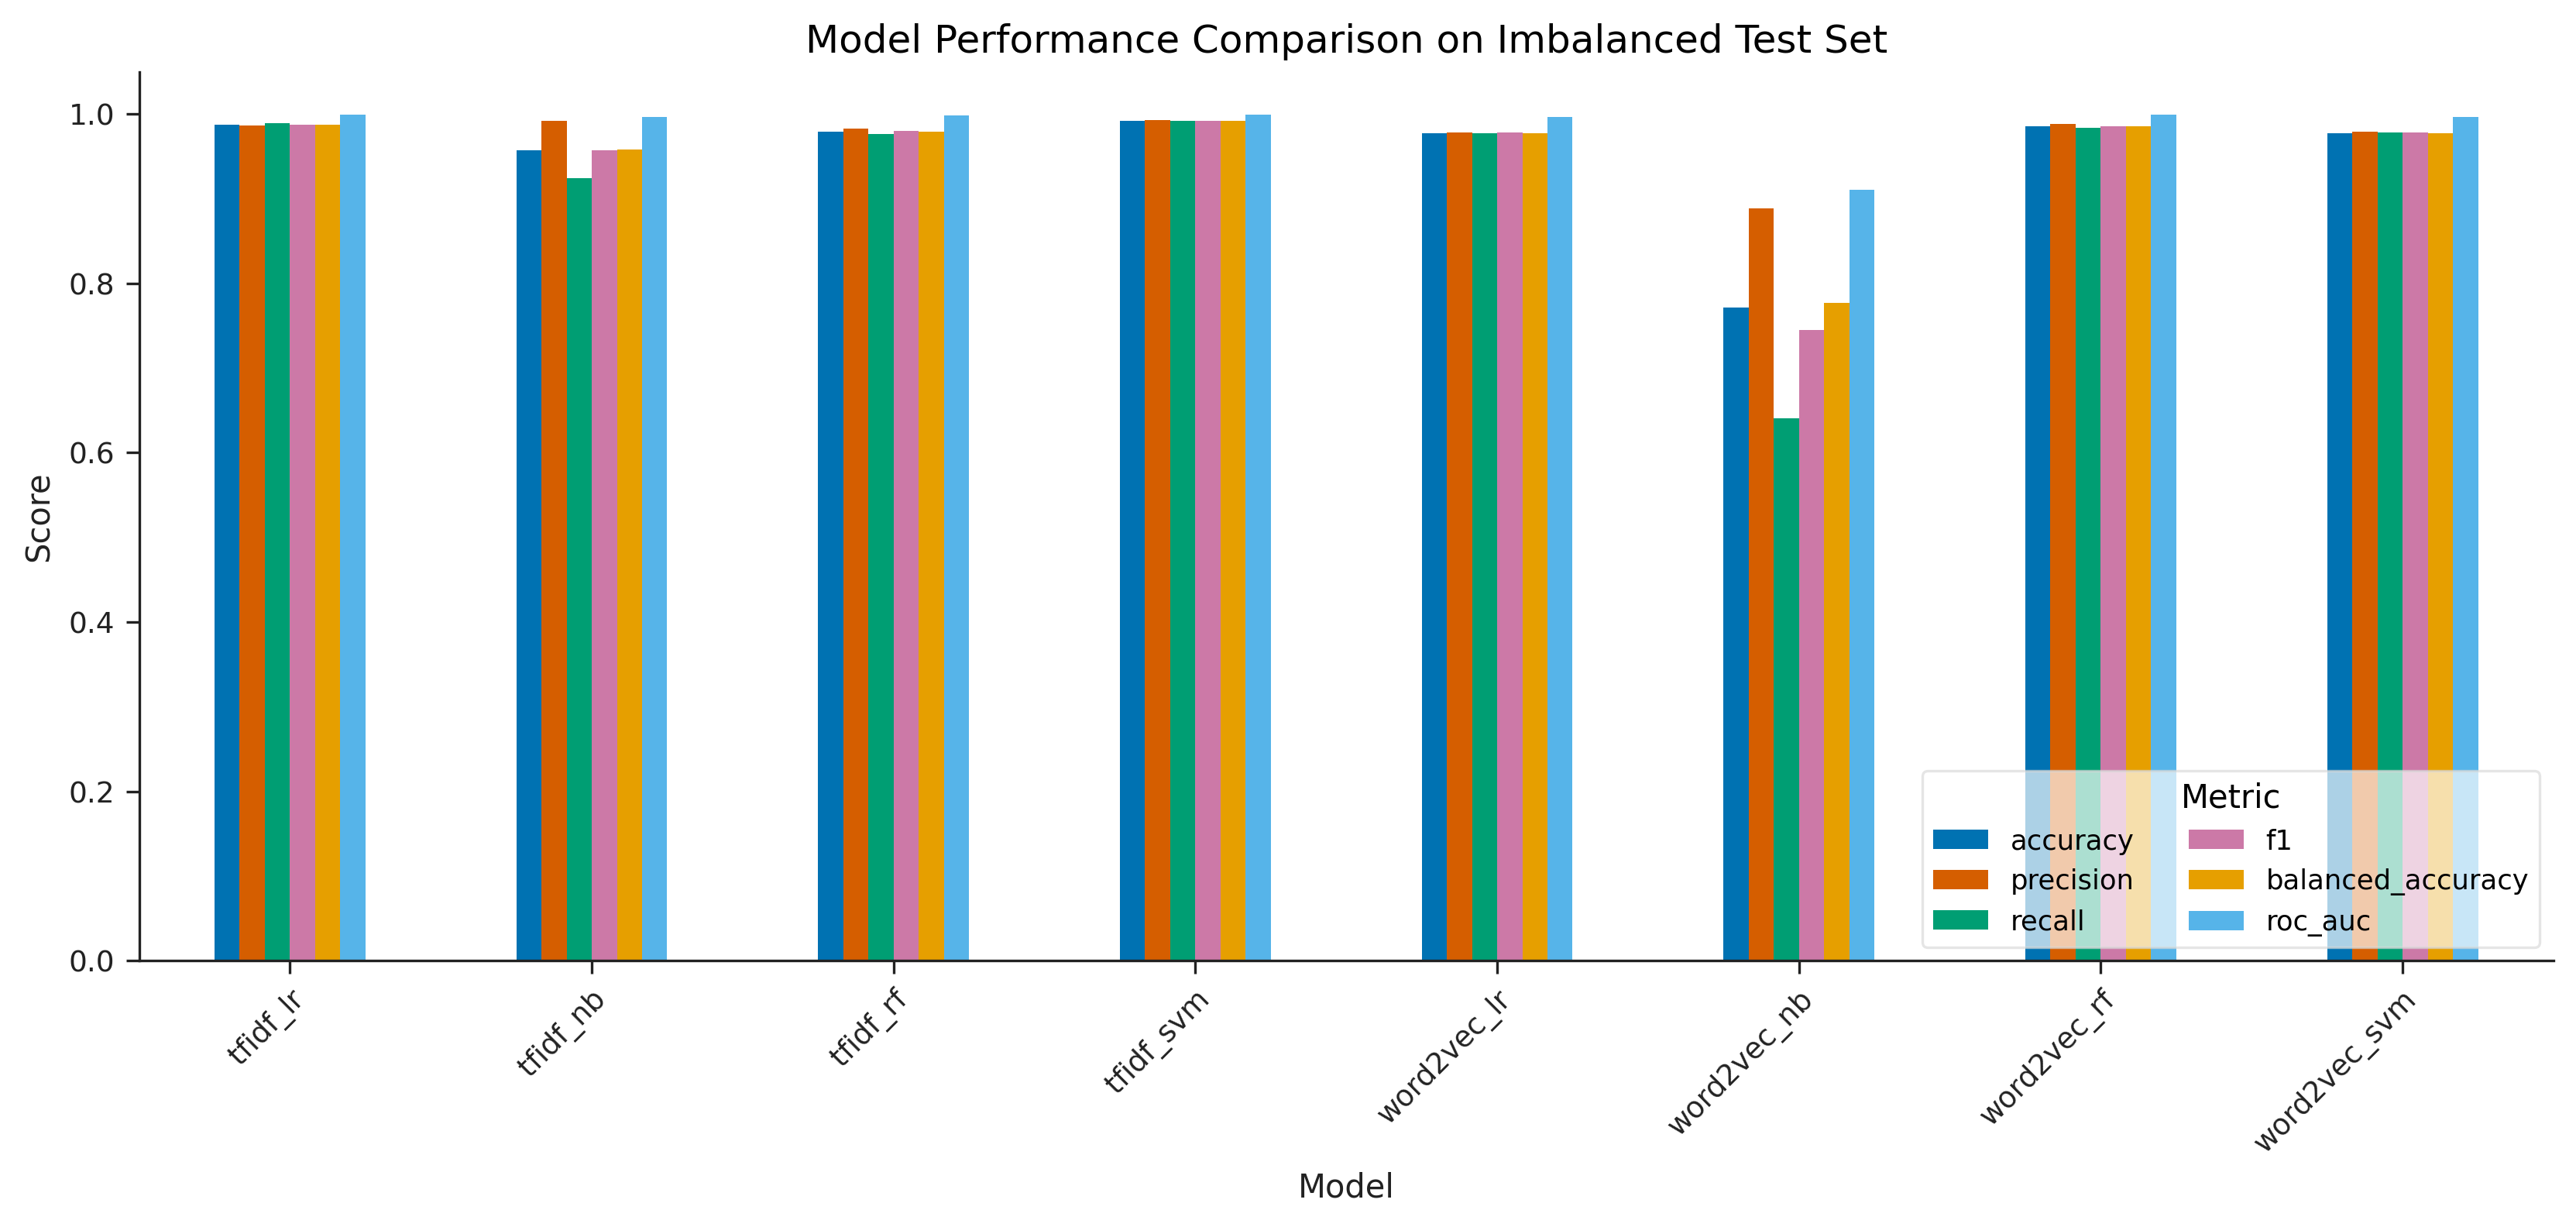

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/confusion_matrix_tfidf_nb.png


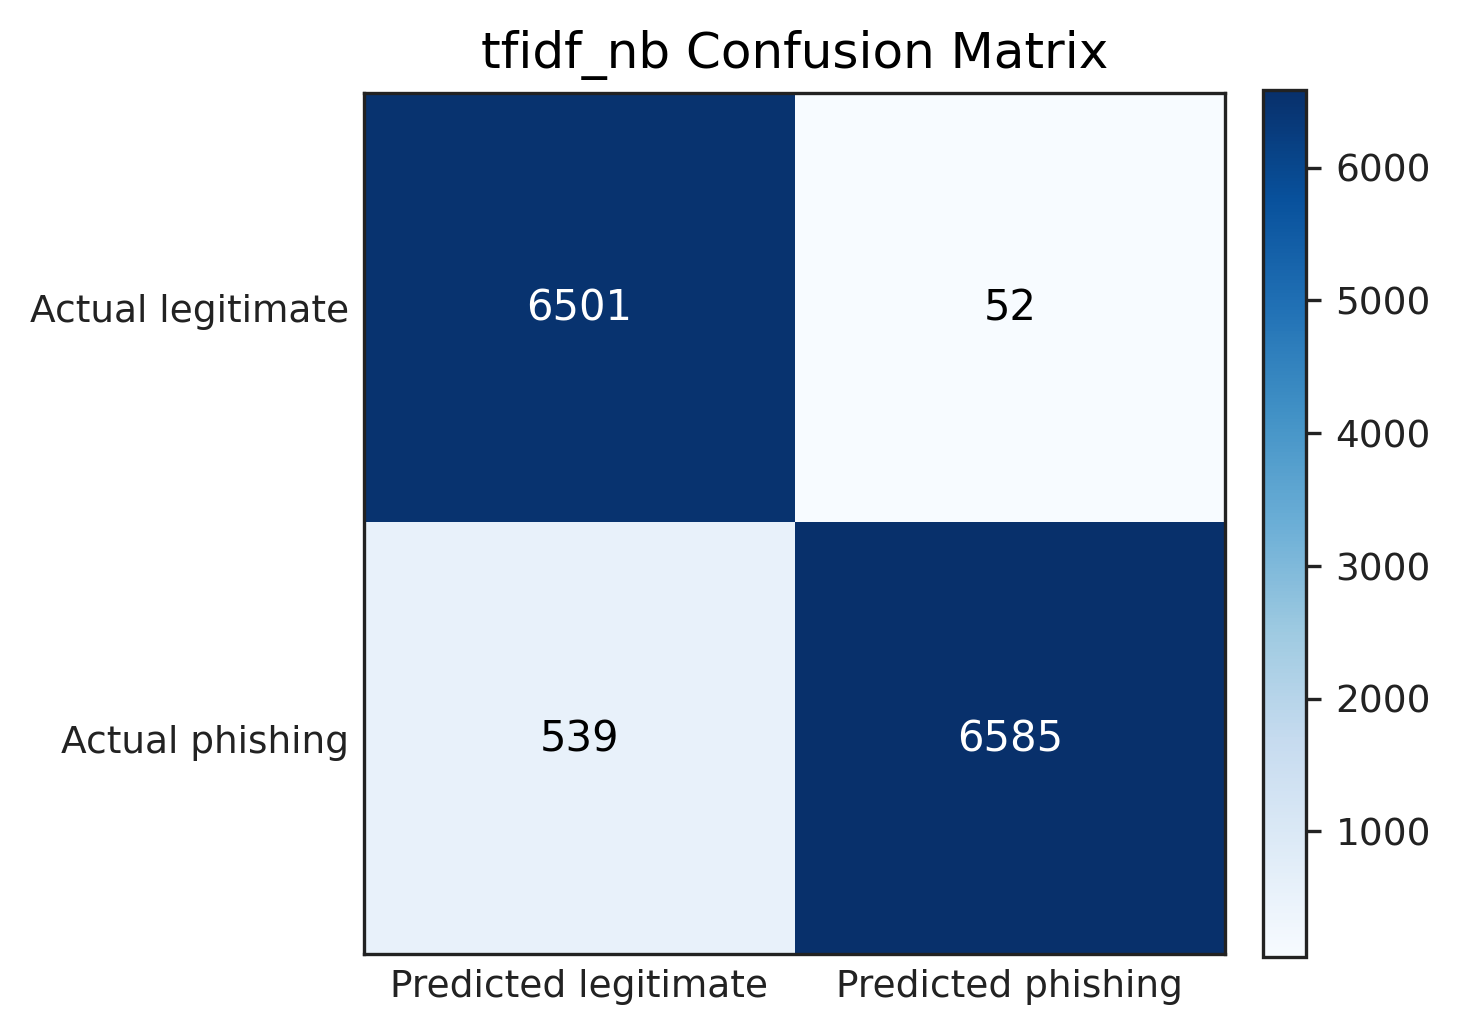

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_roc_tfidf.png


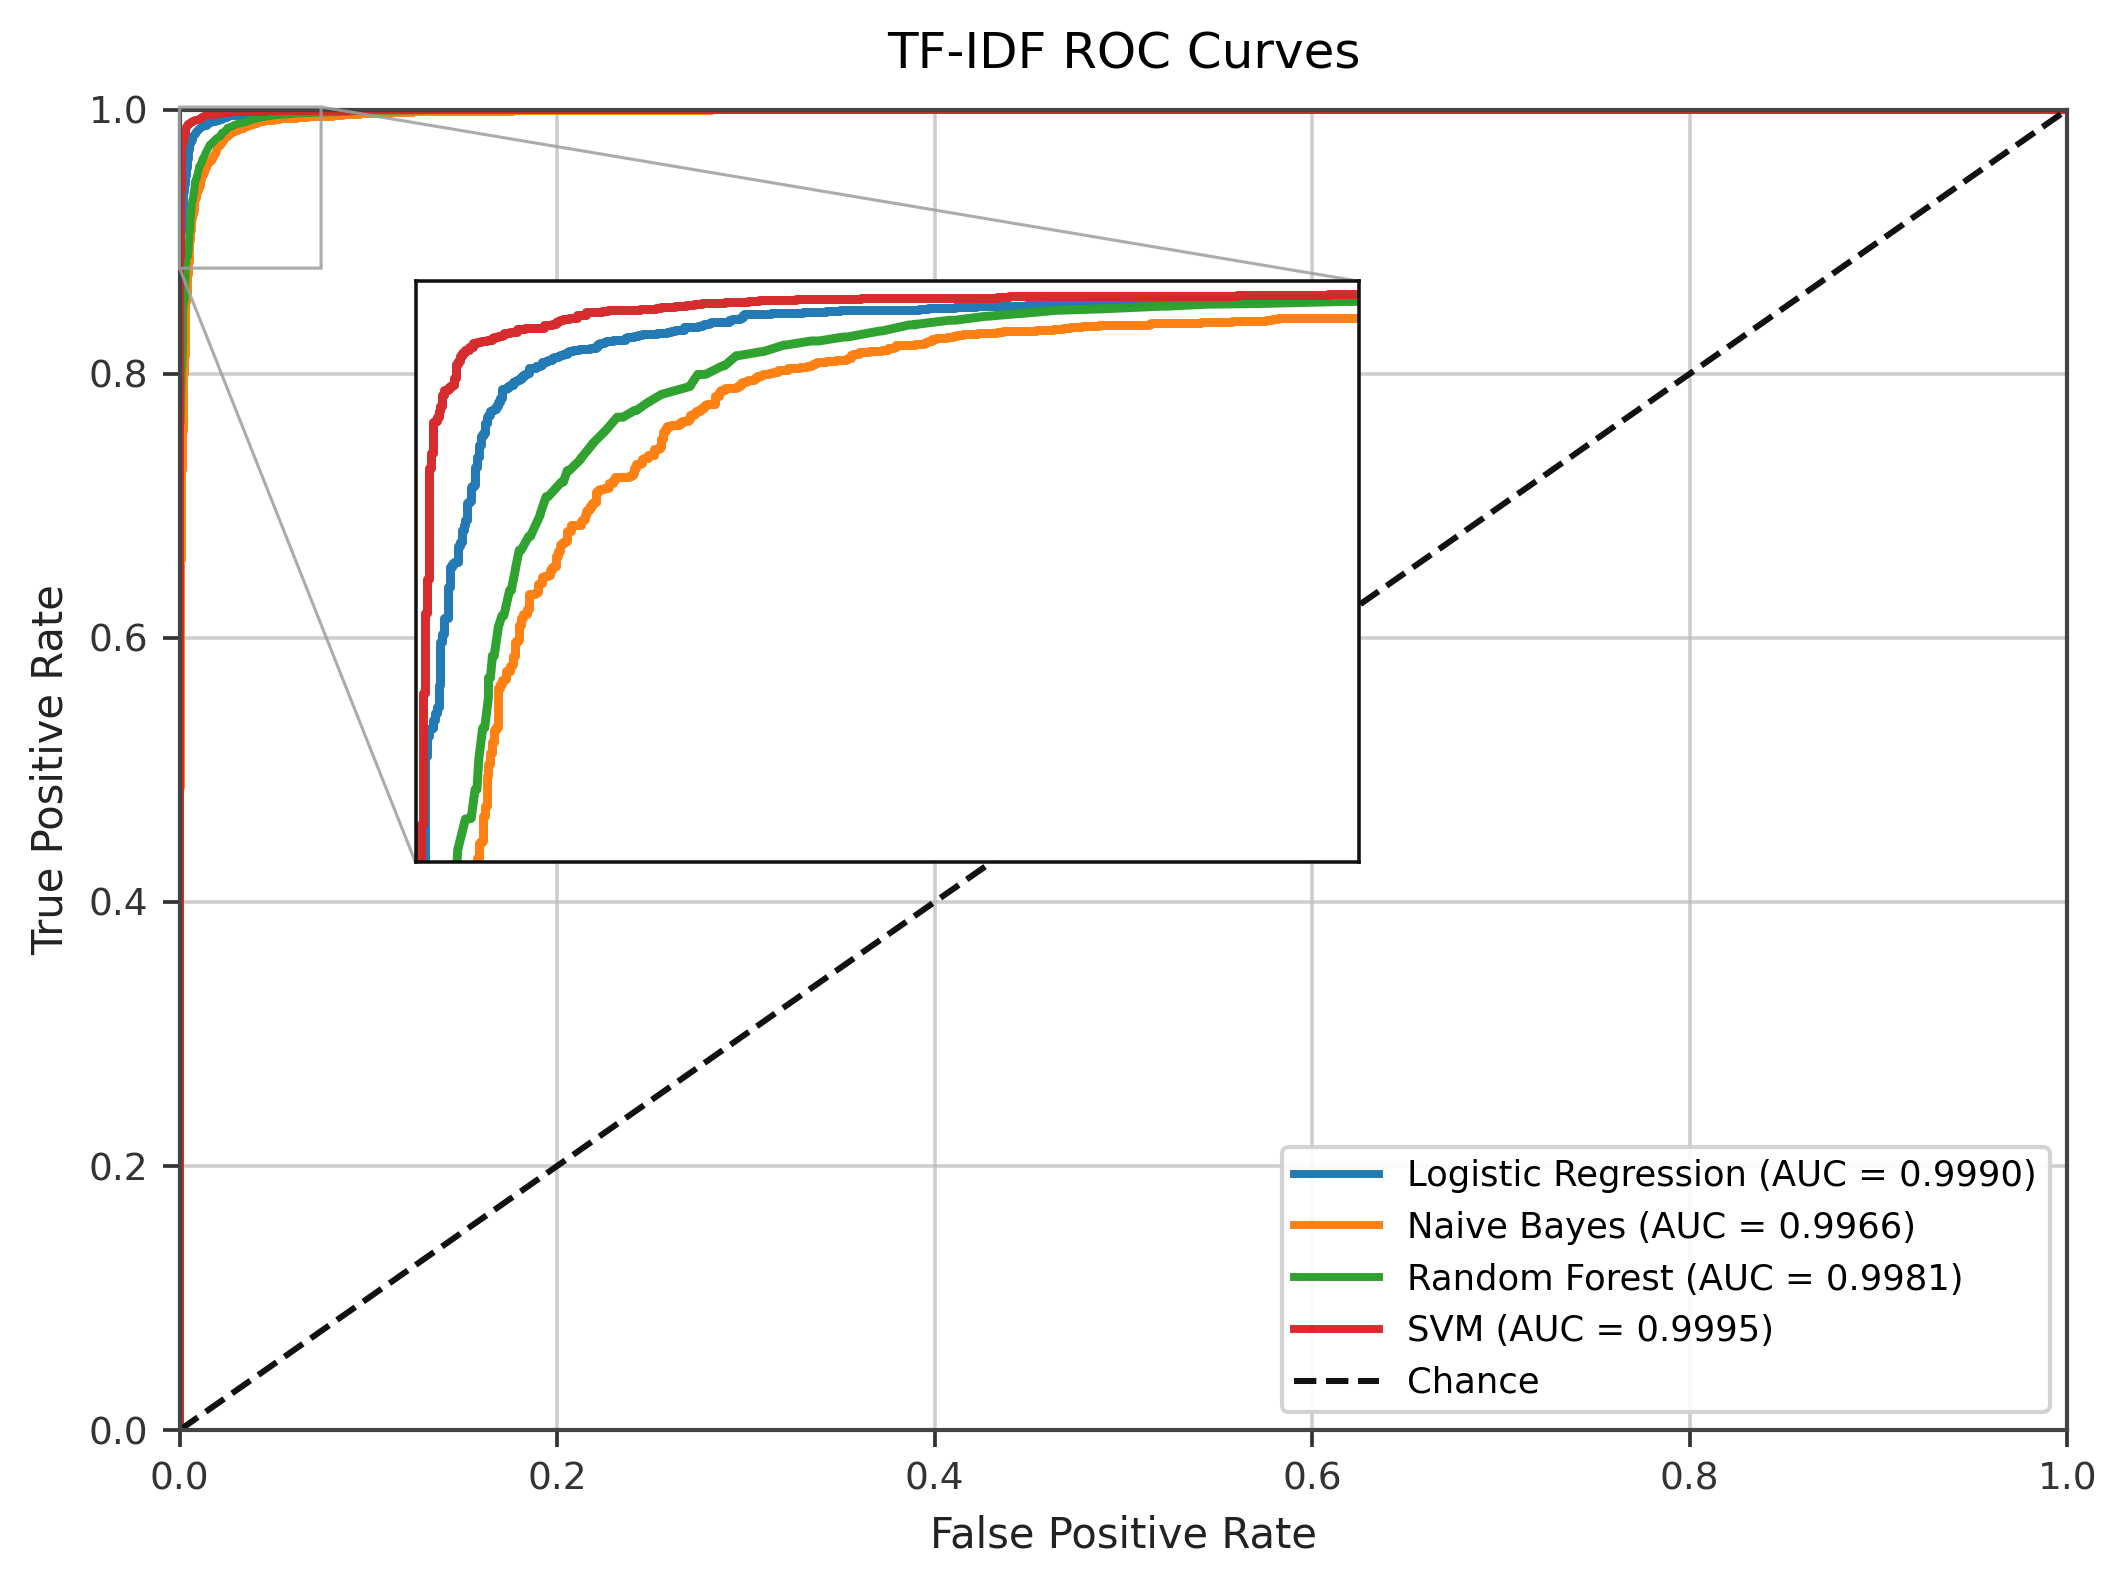

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_roc_word2vec.png


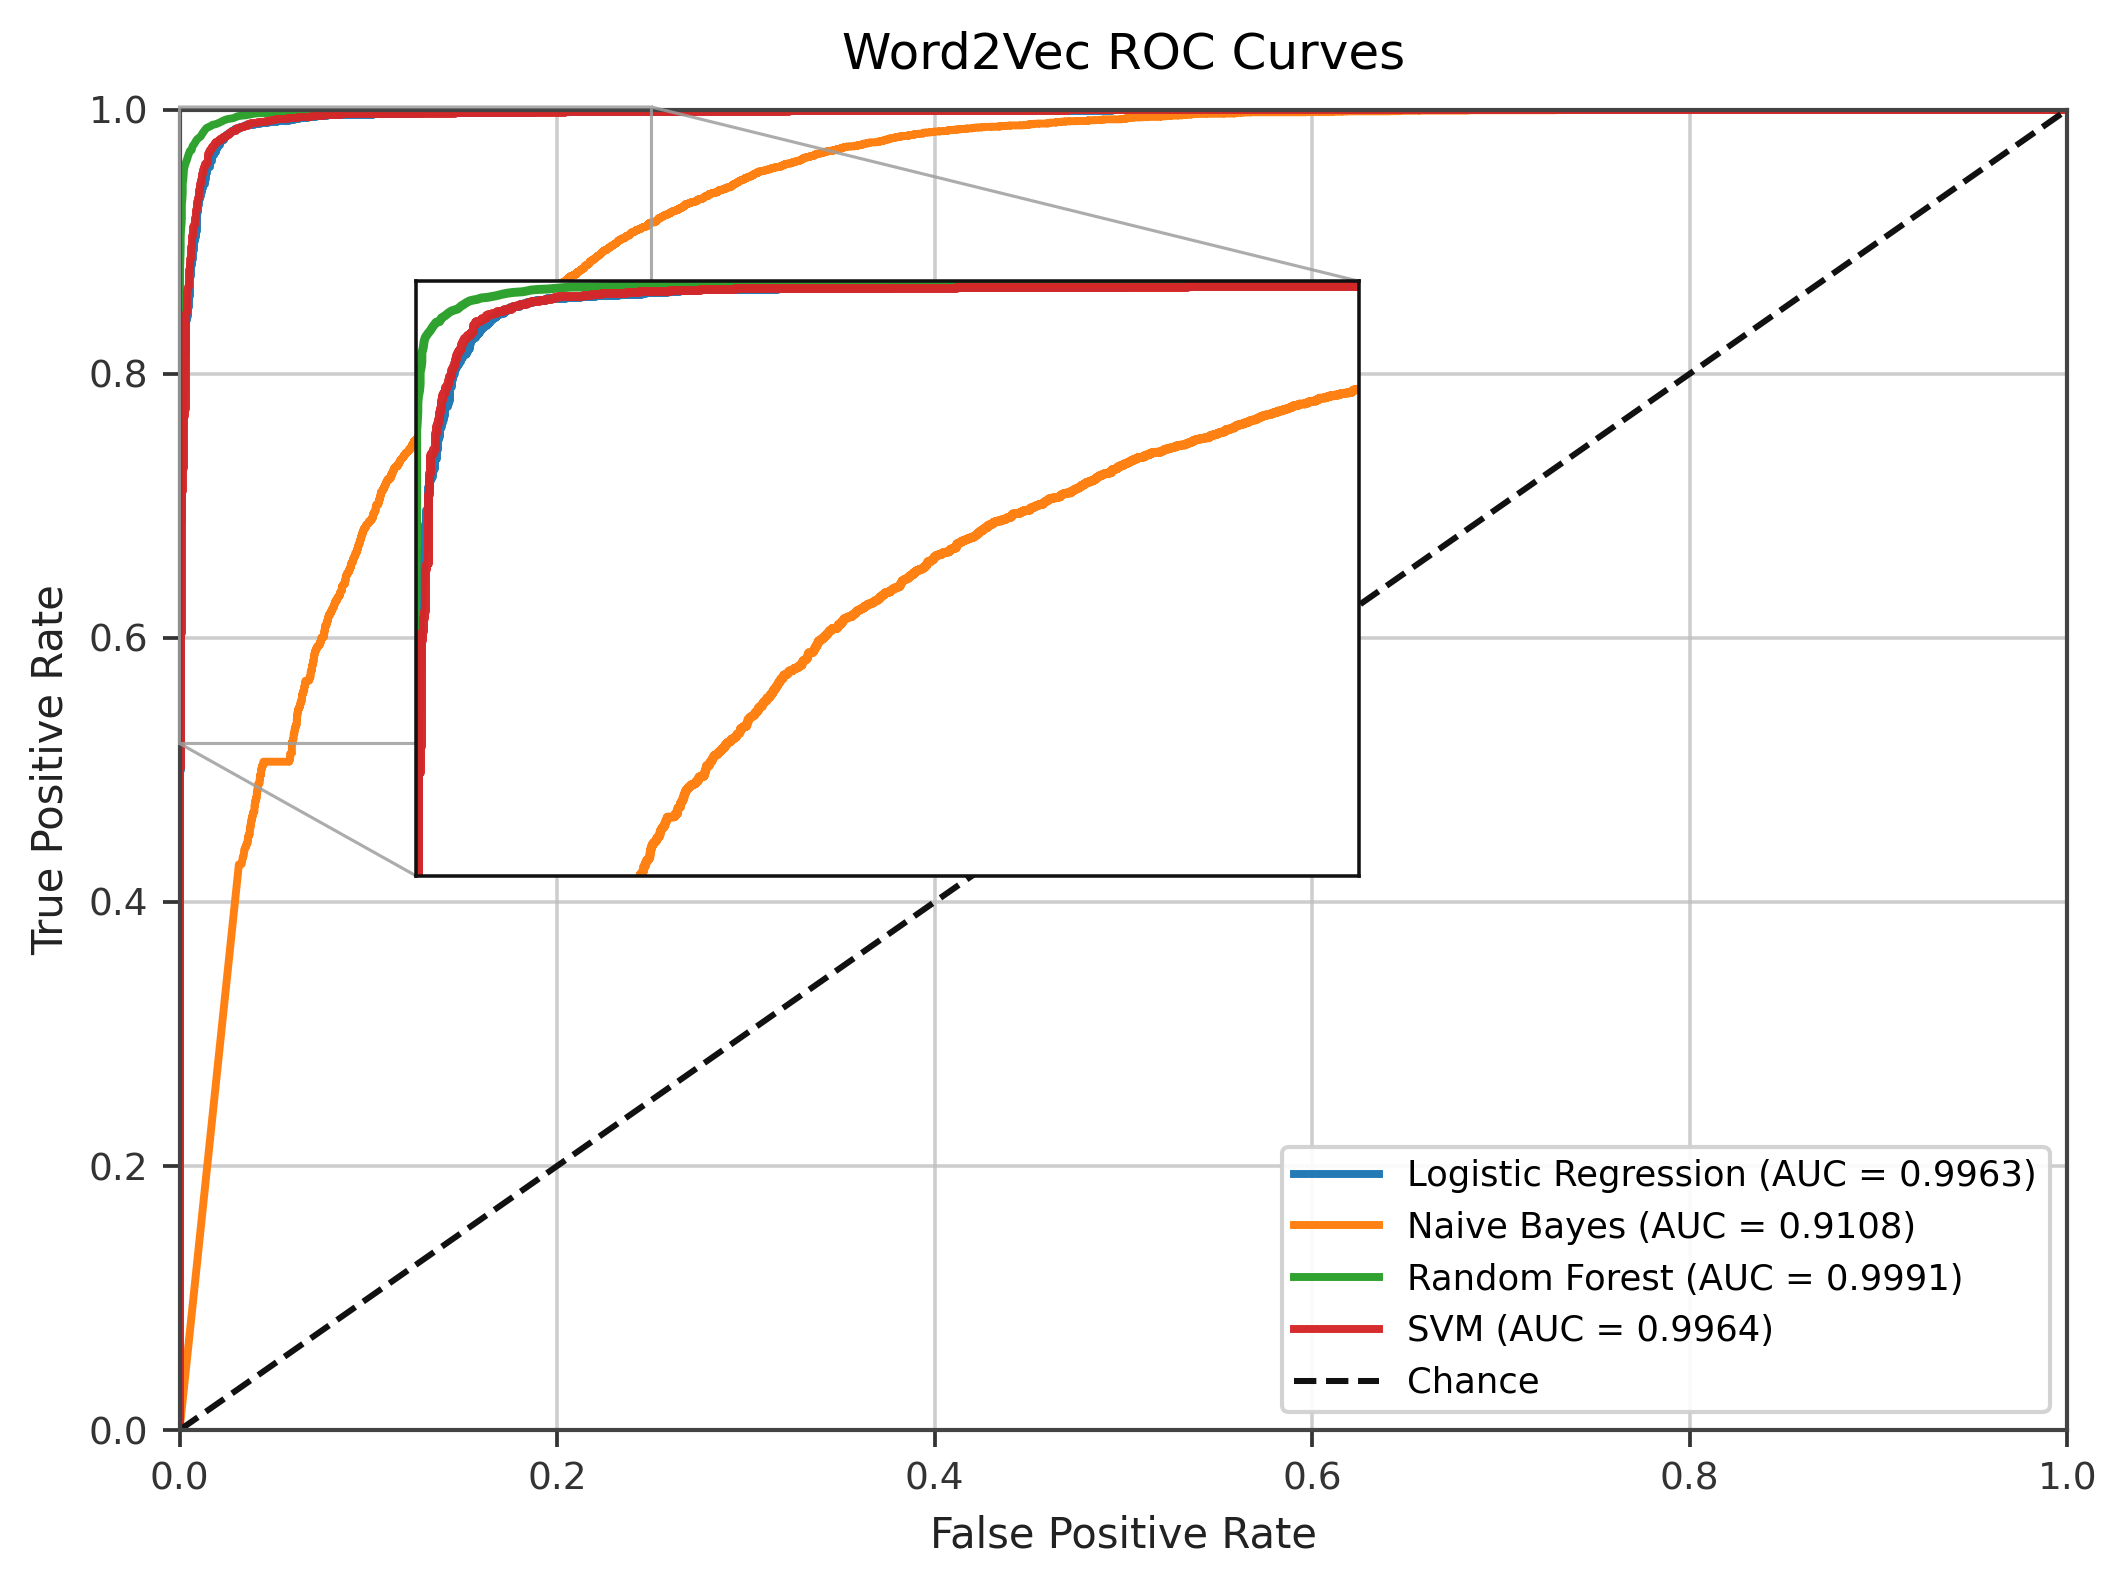

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_roc_openai_embeddings.png


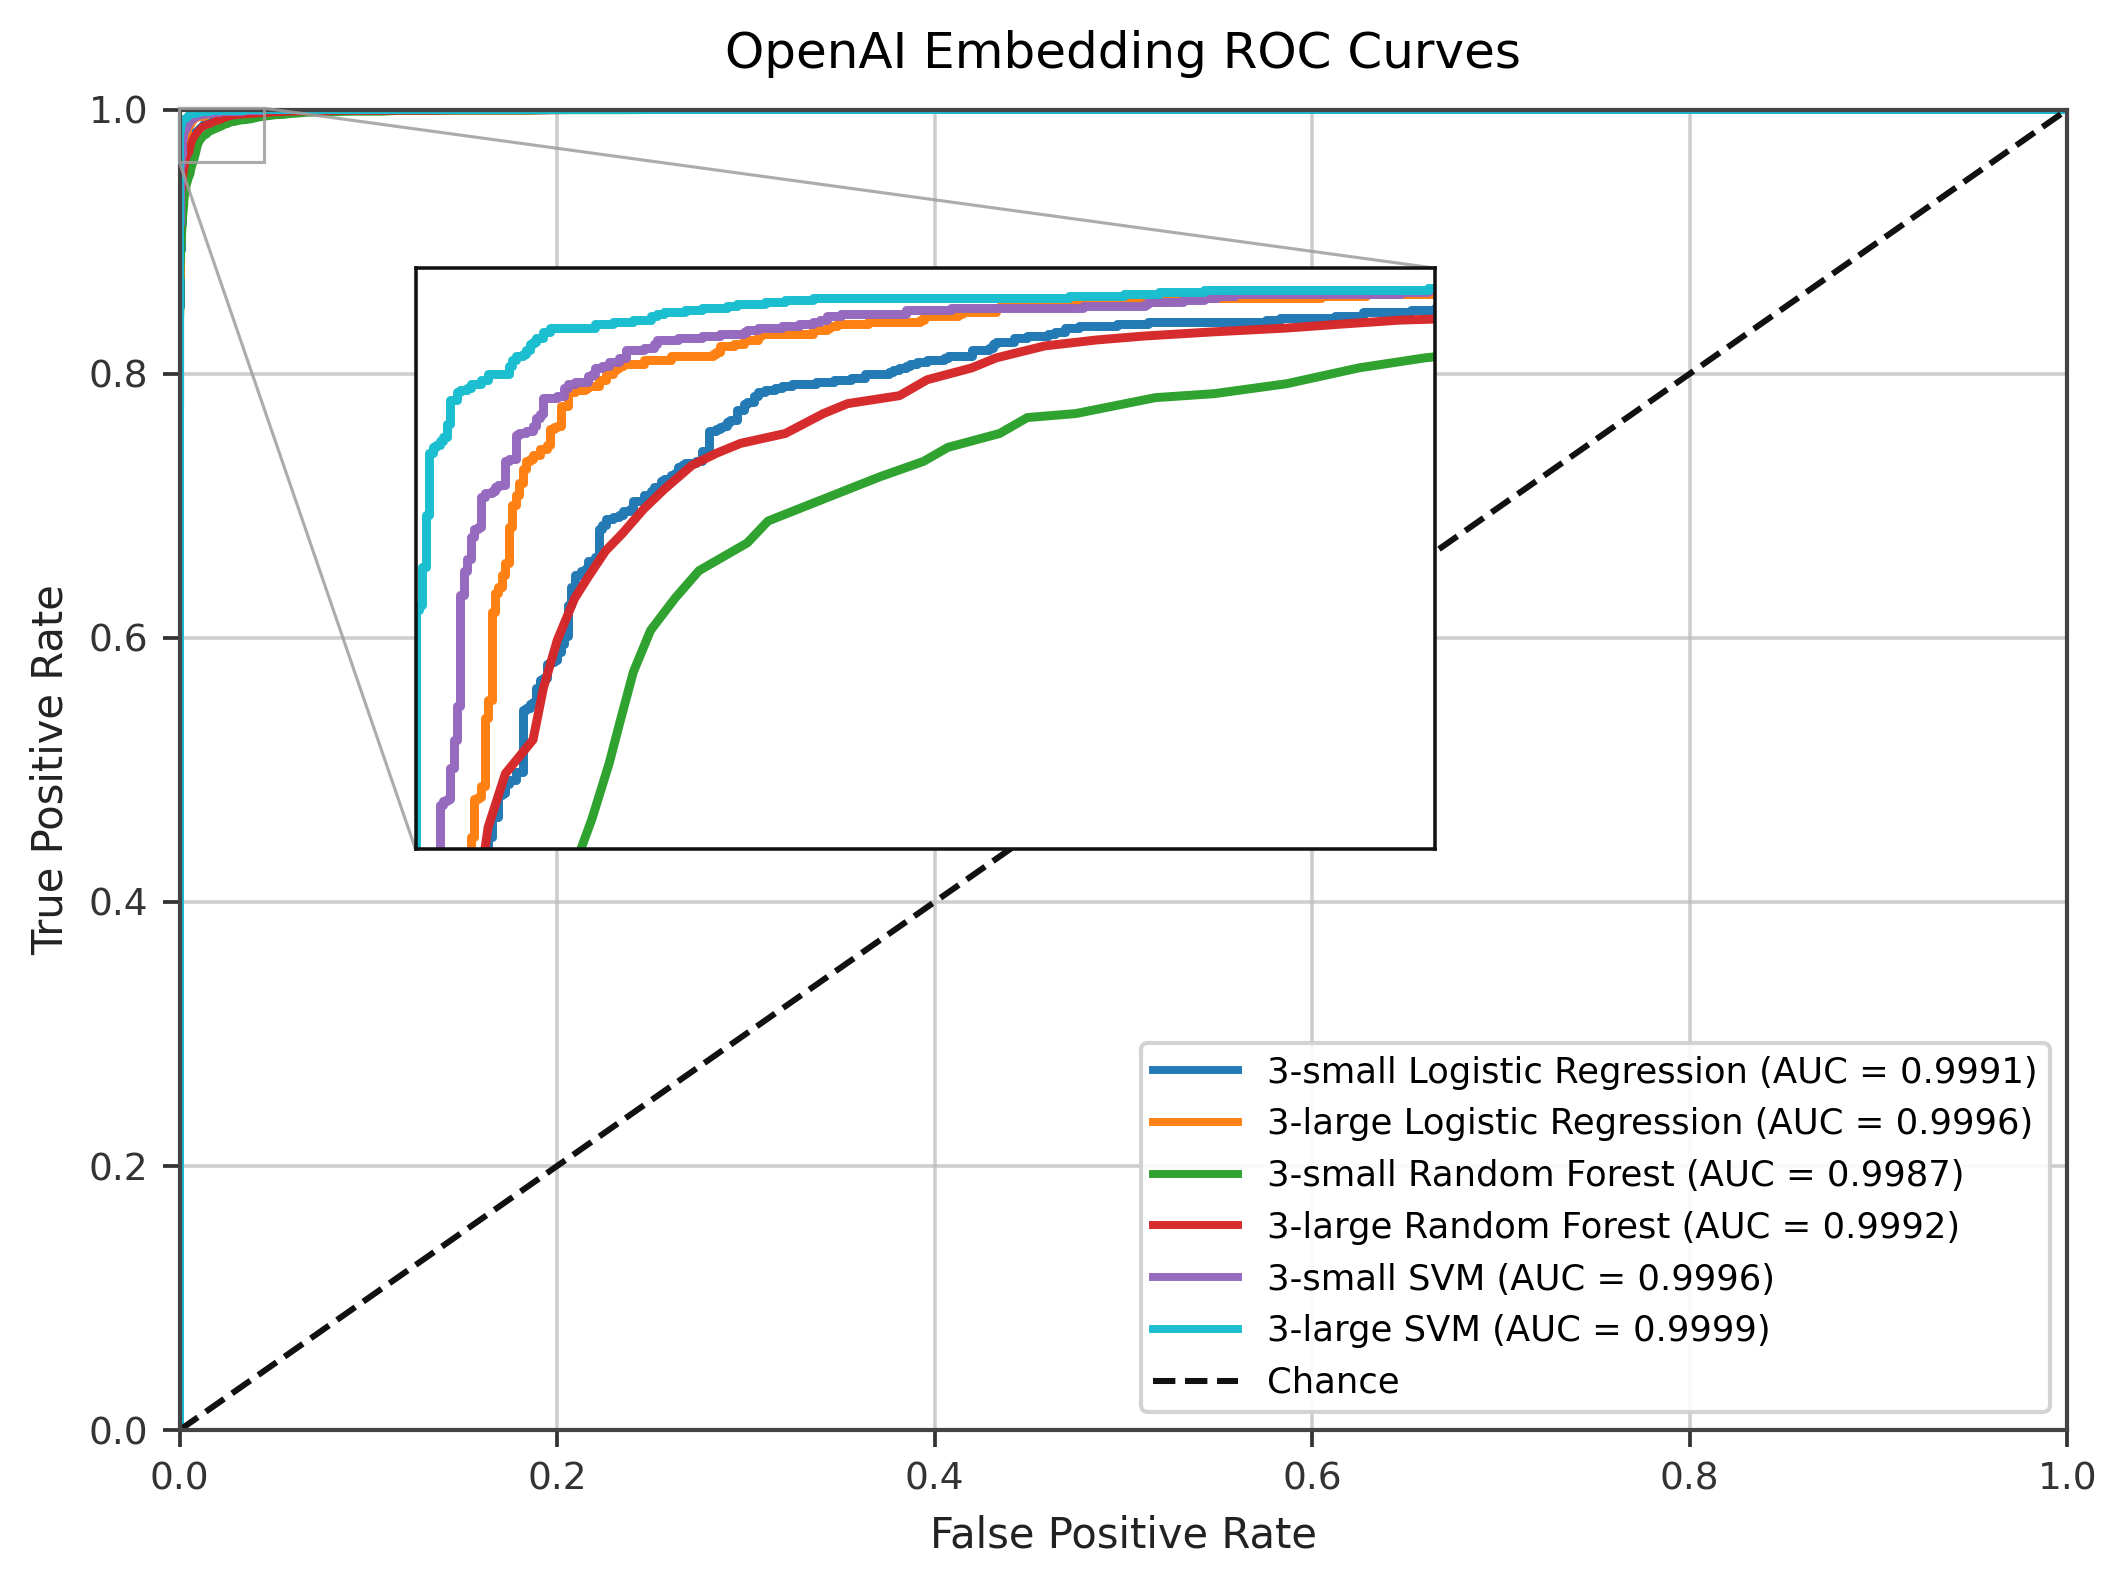

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_roc_champion_comparison.png


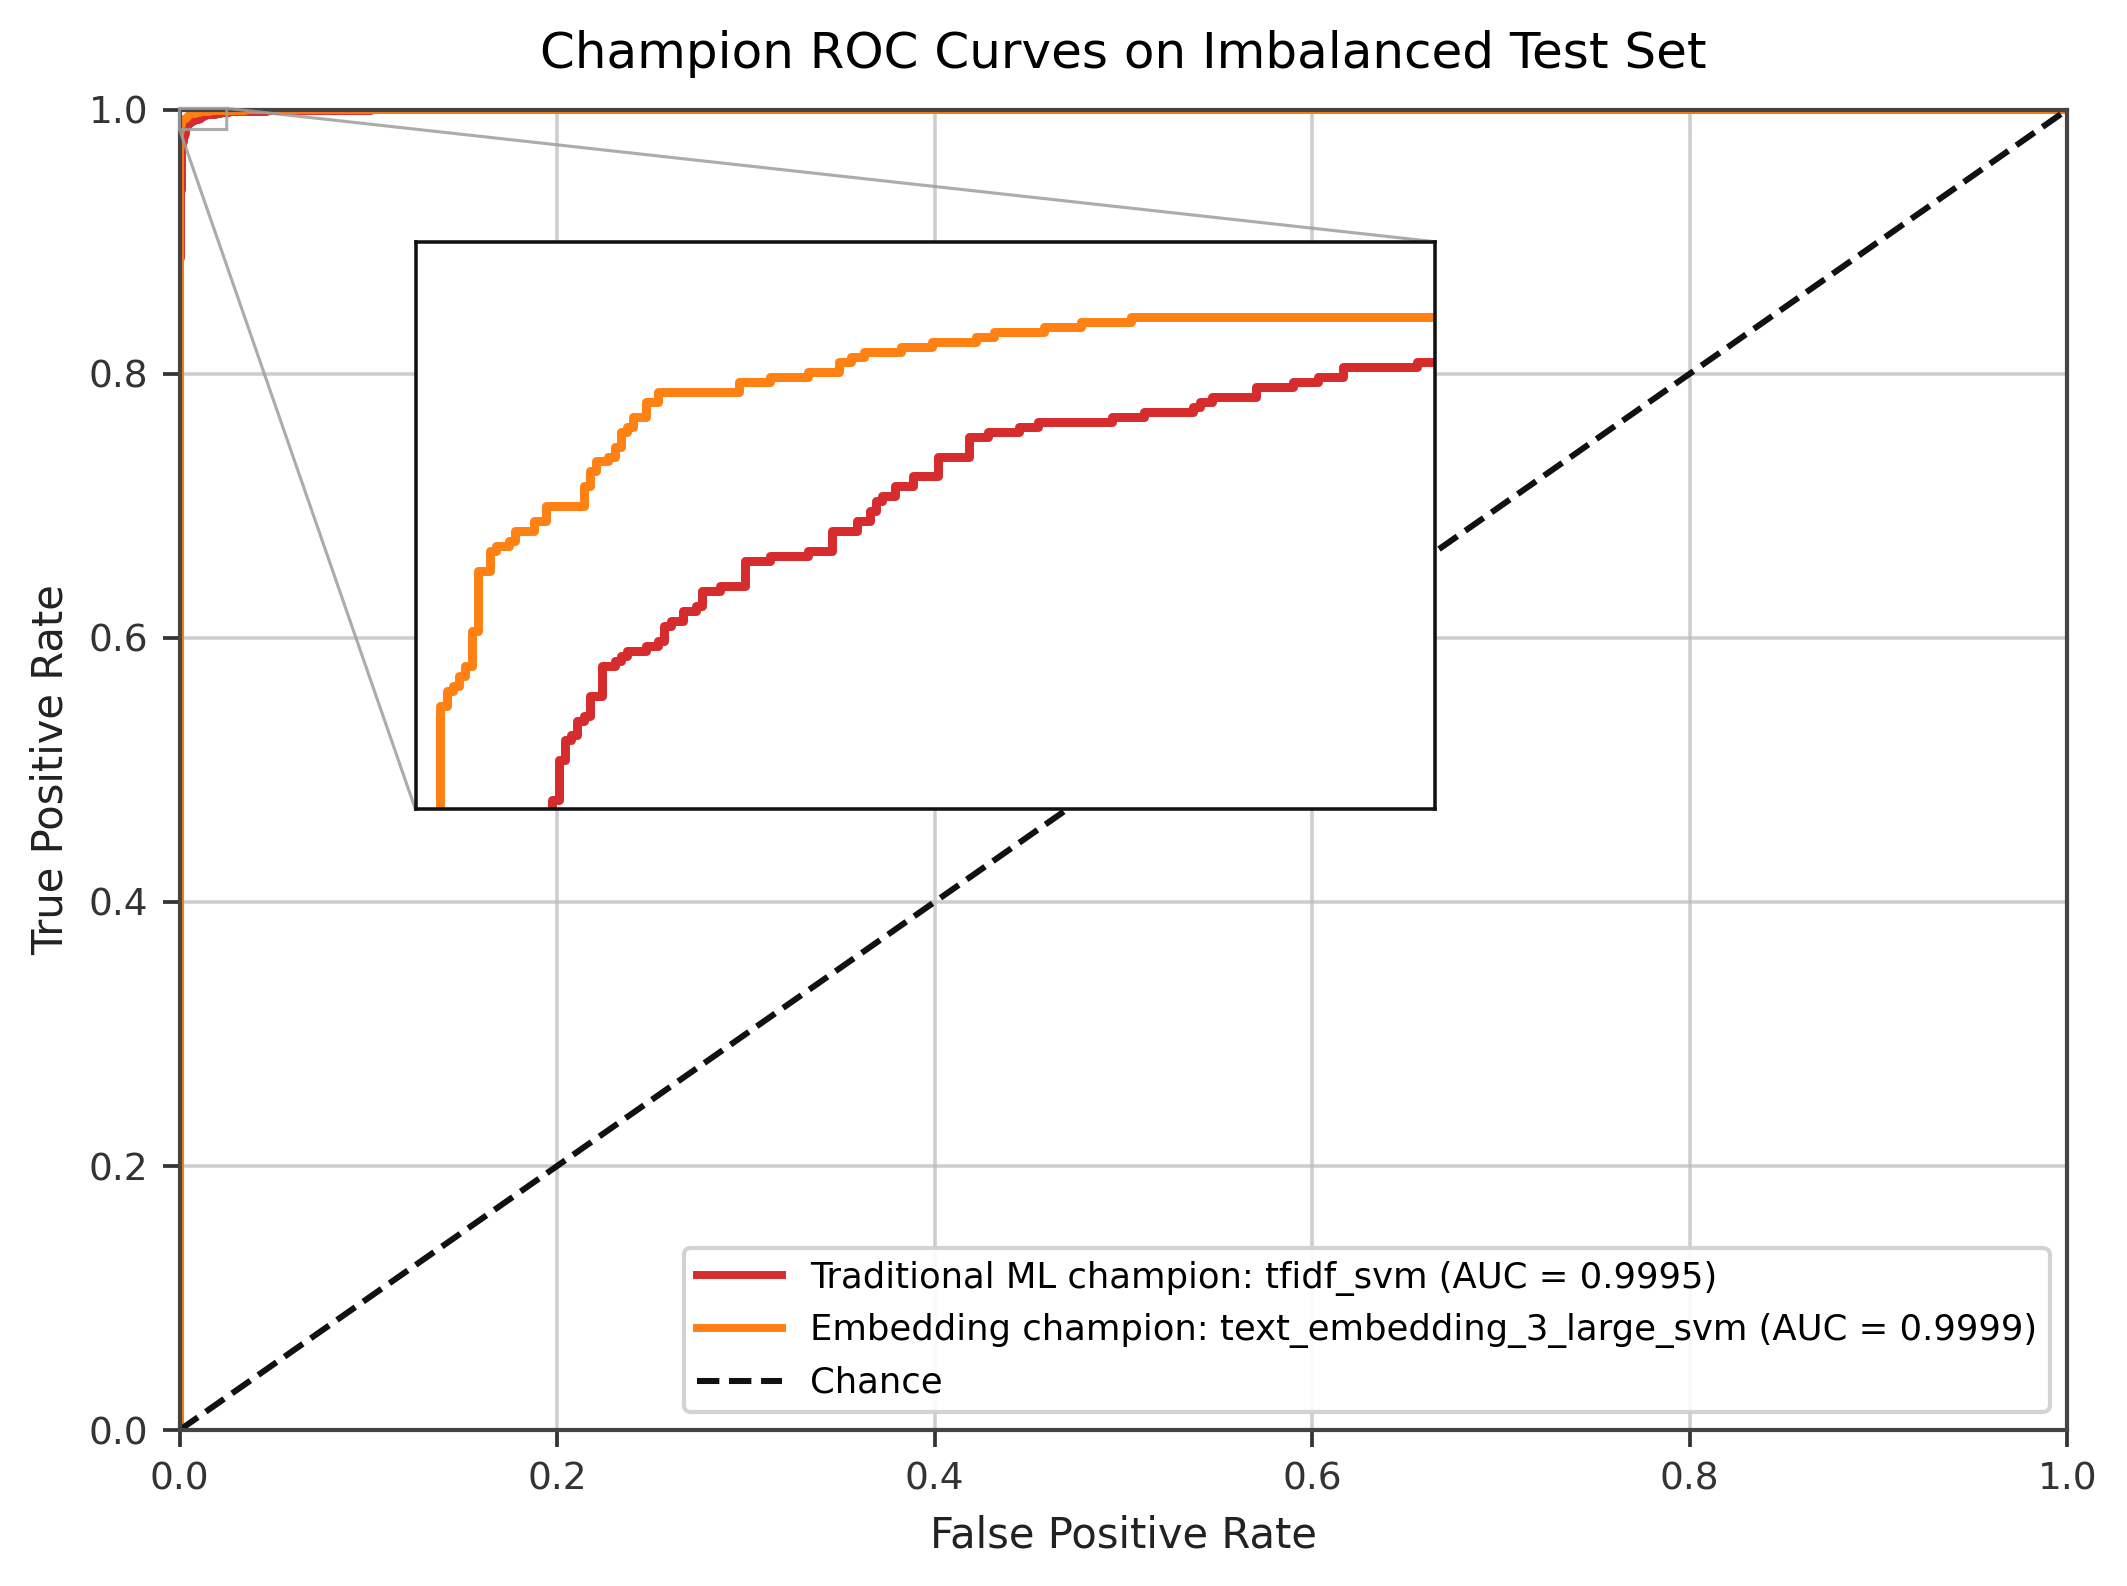

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_fp_fn_comparison.png


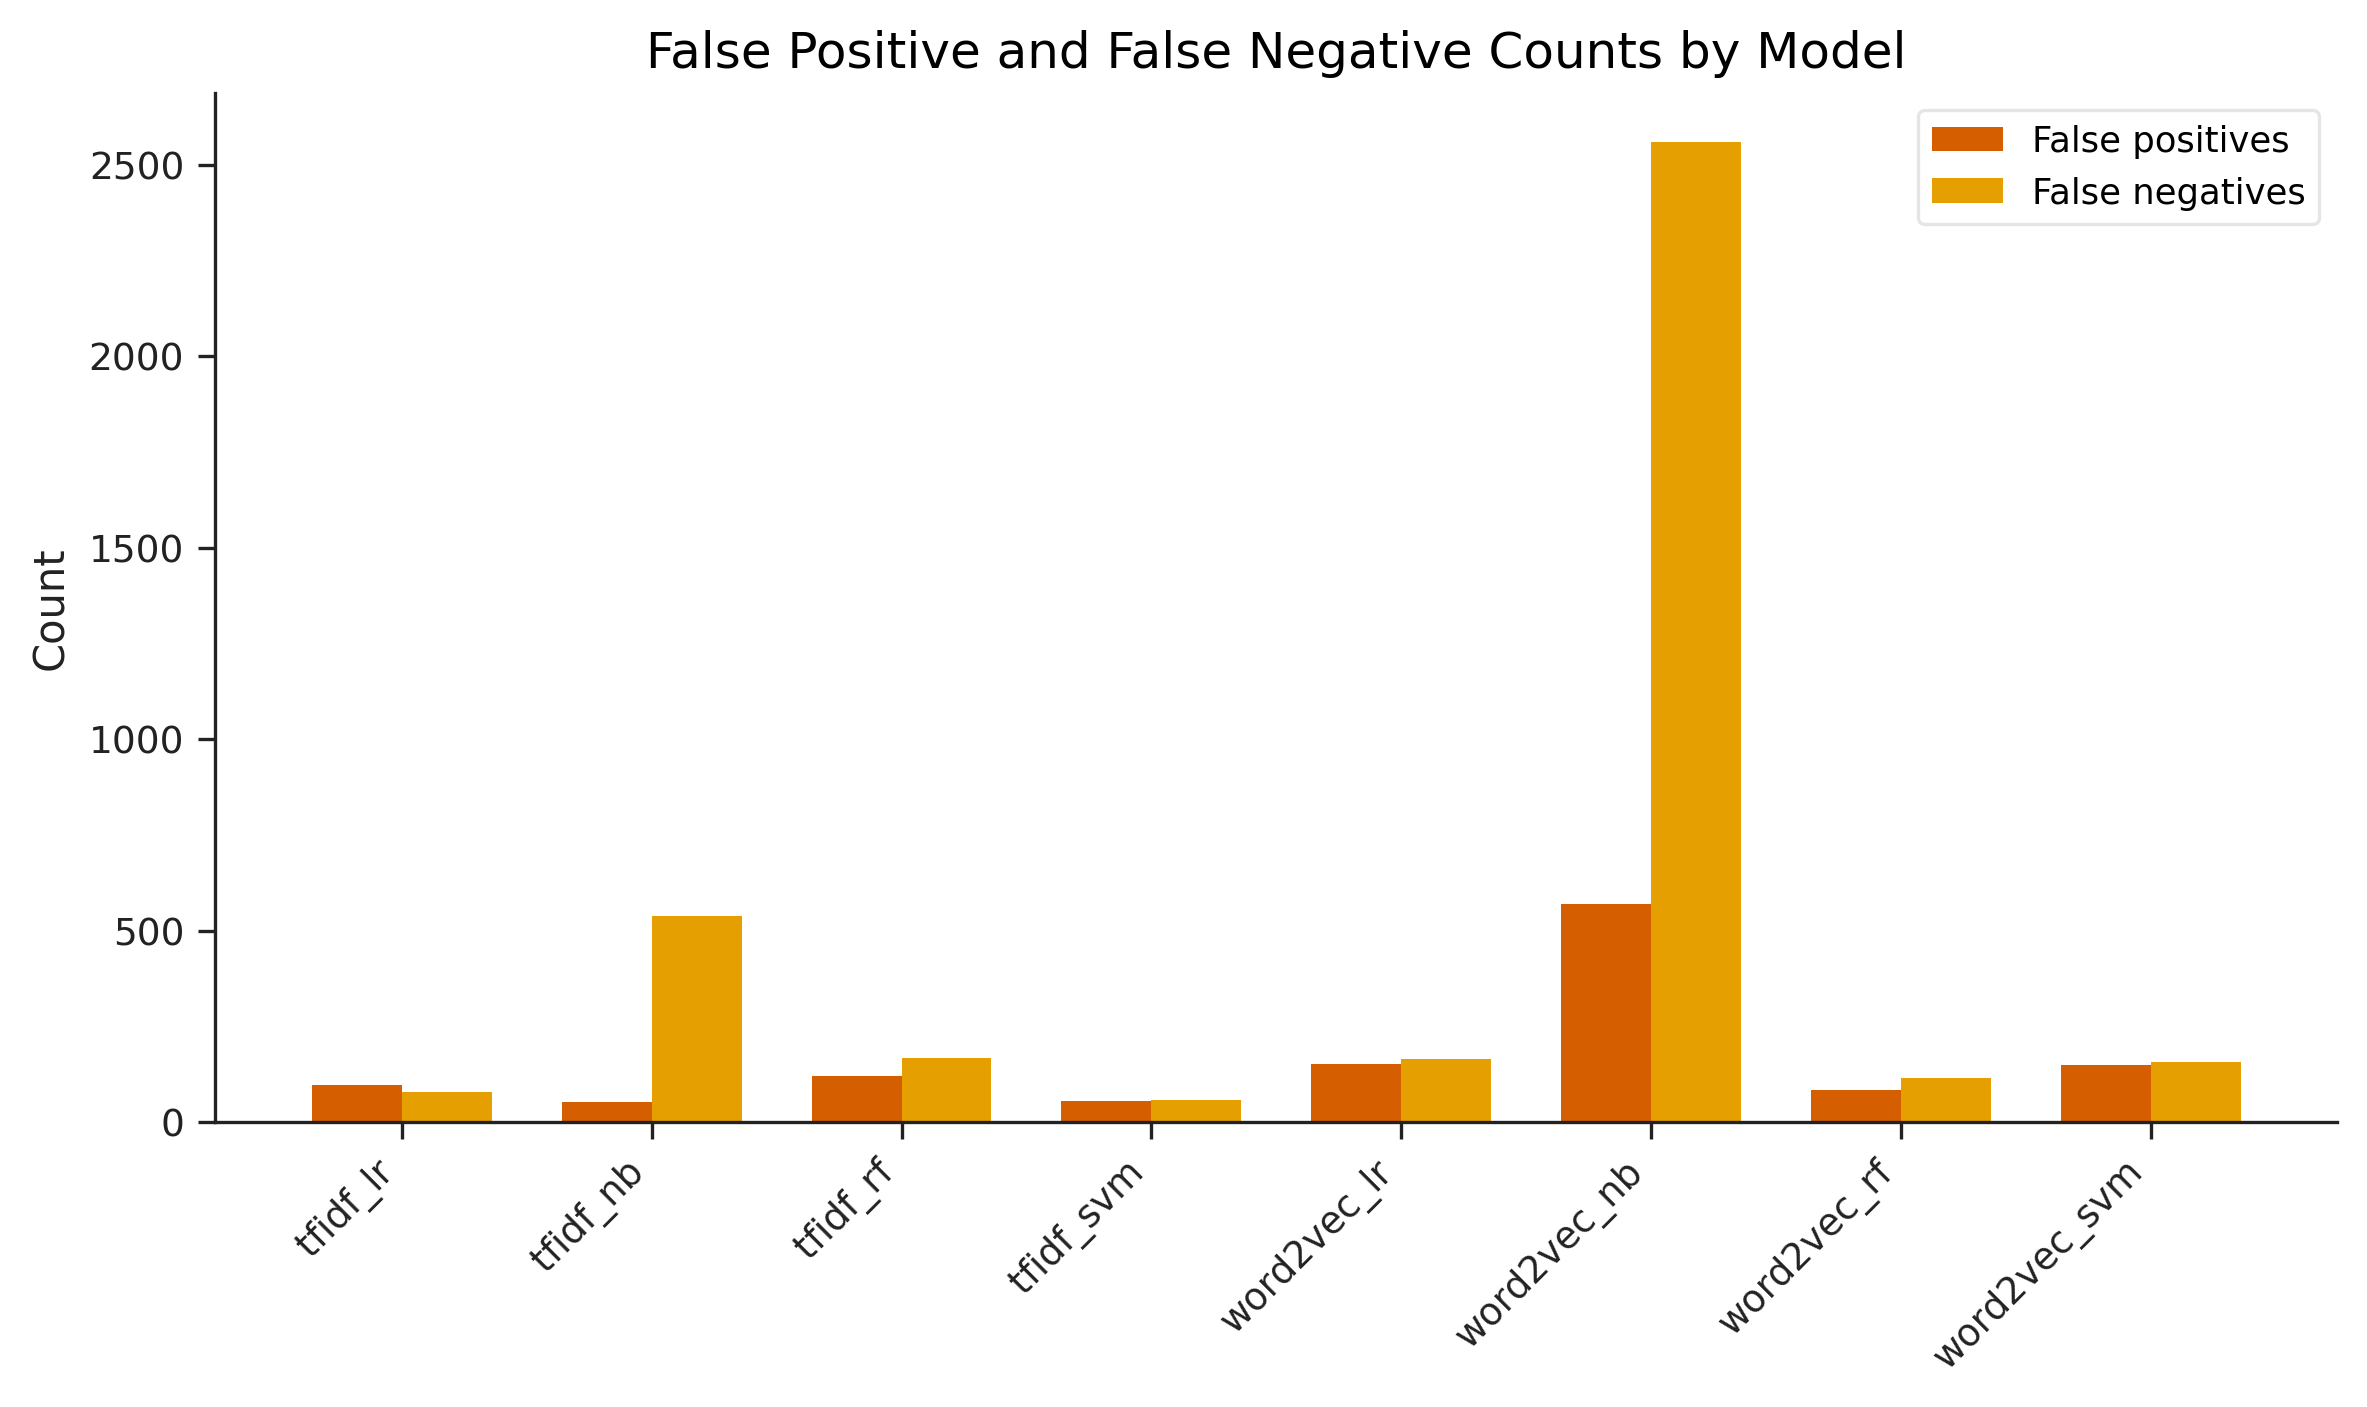

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_robustness_degradation.png


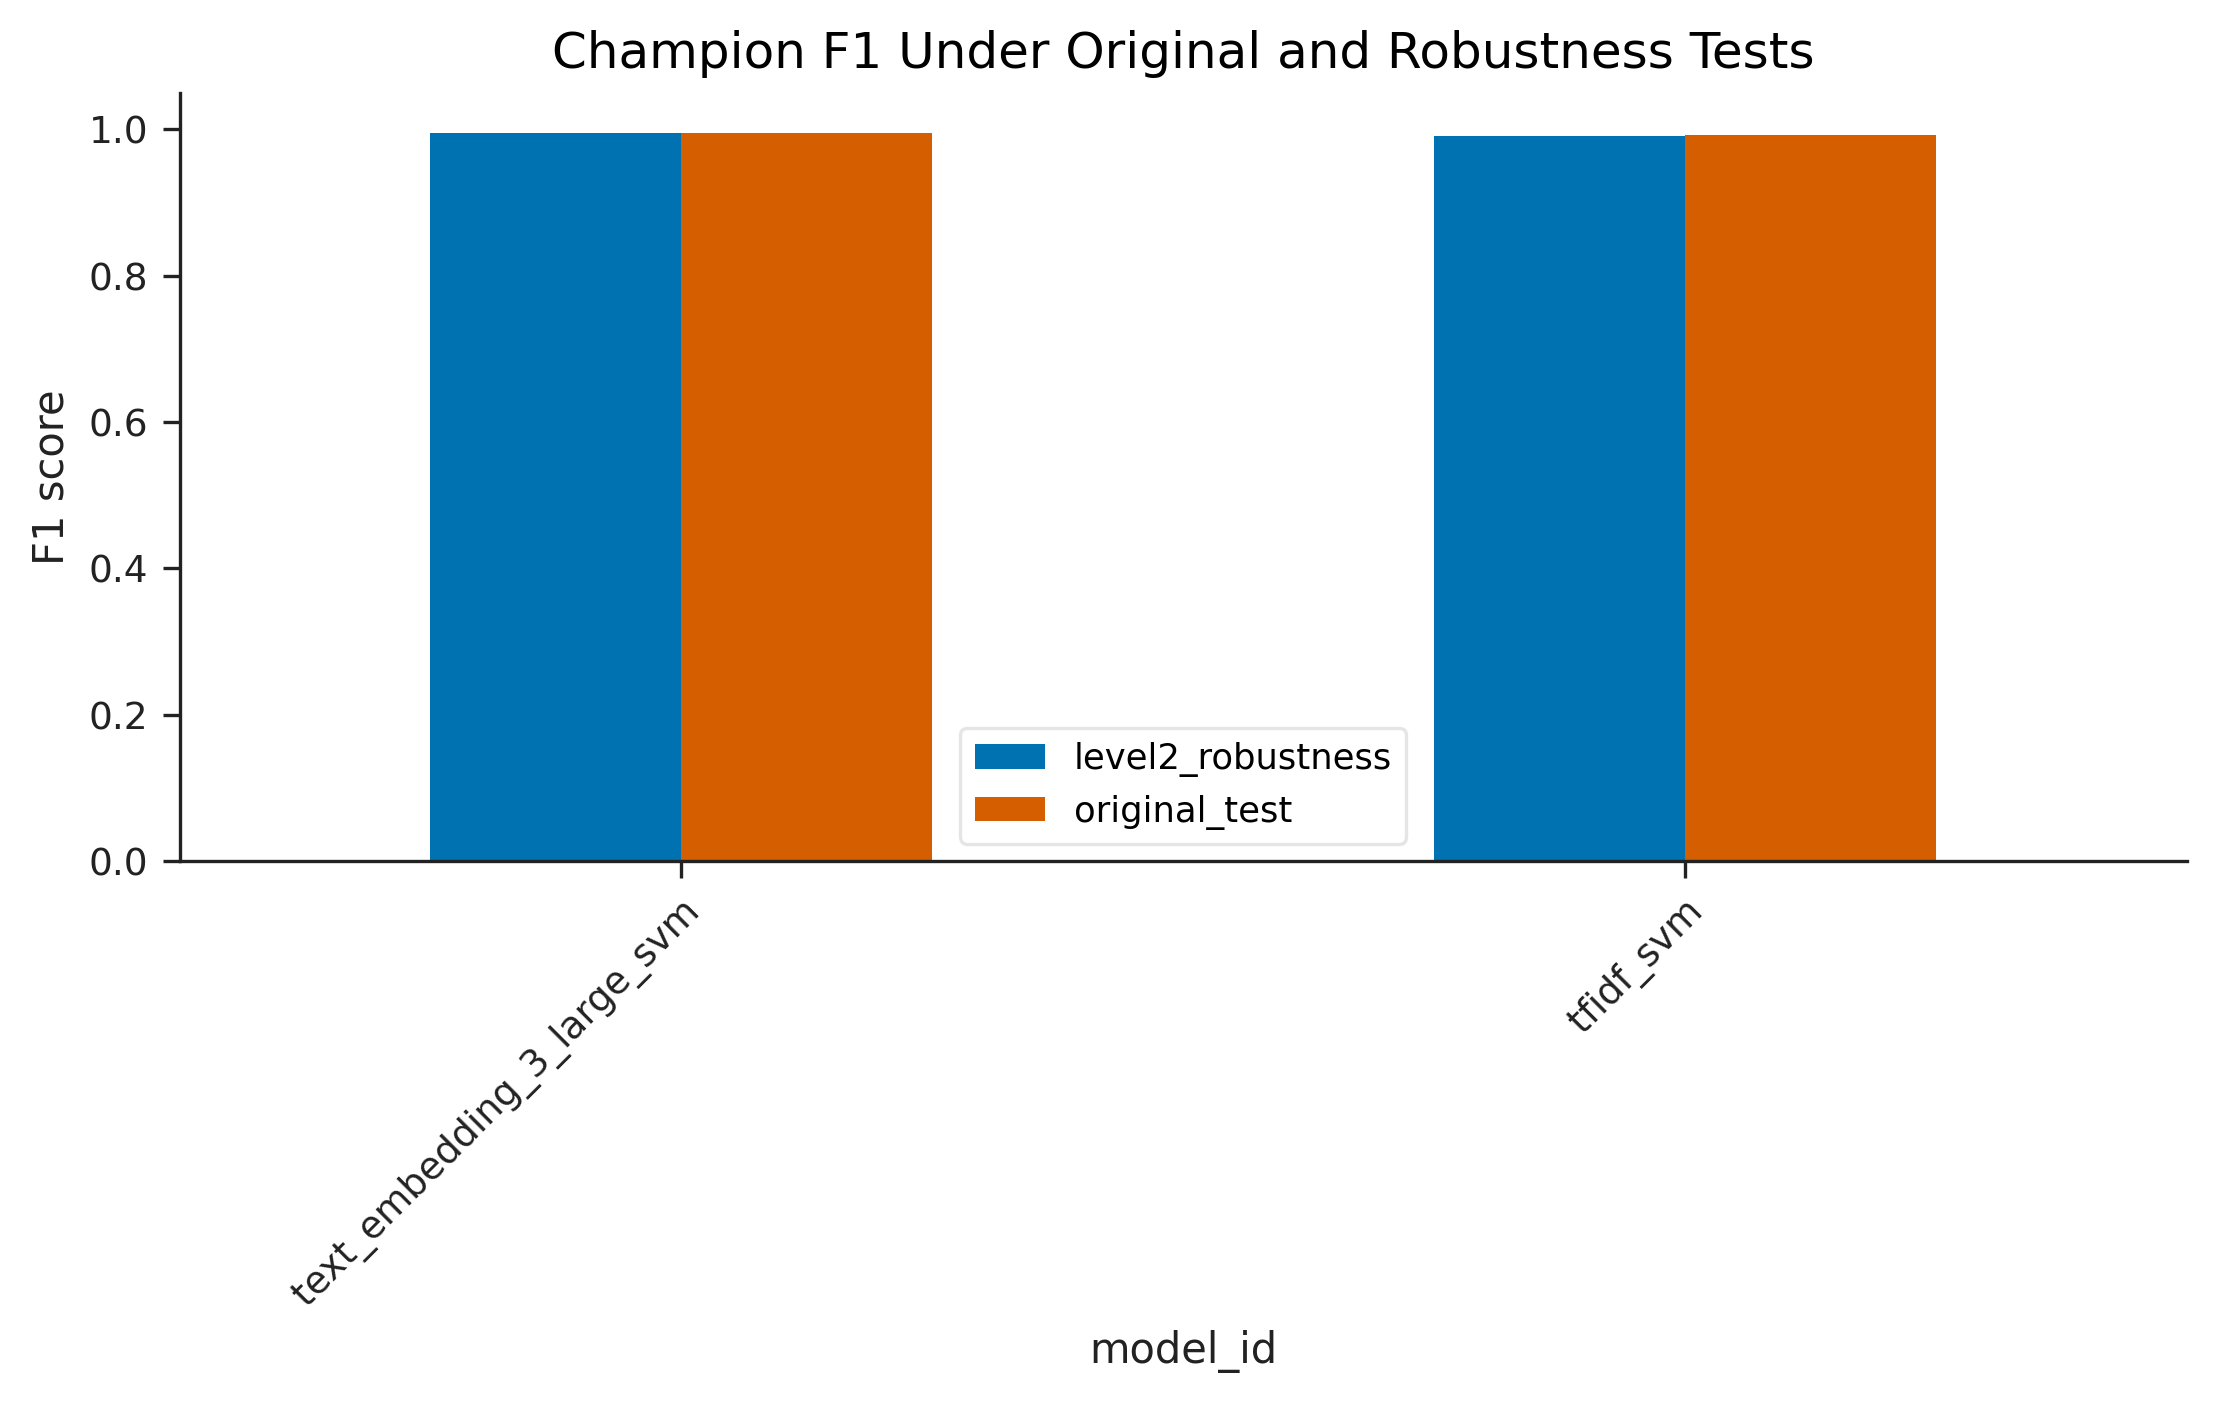

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_projected_runtime_100k.png


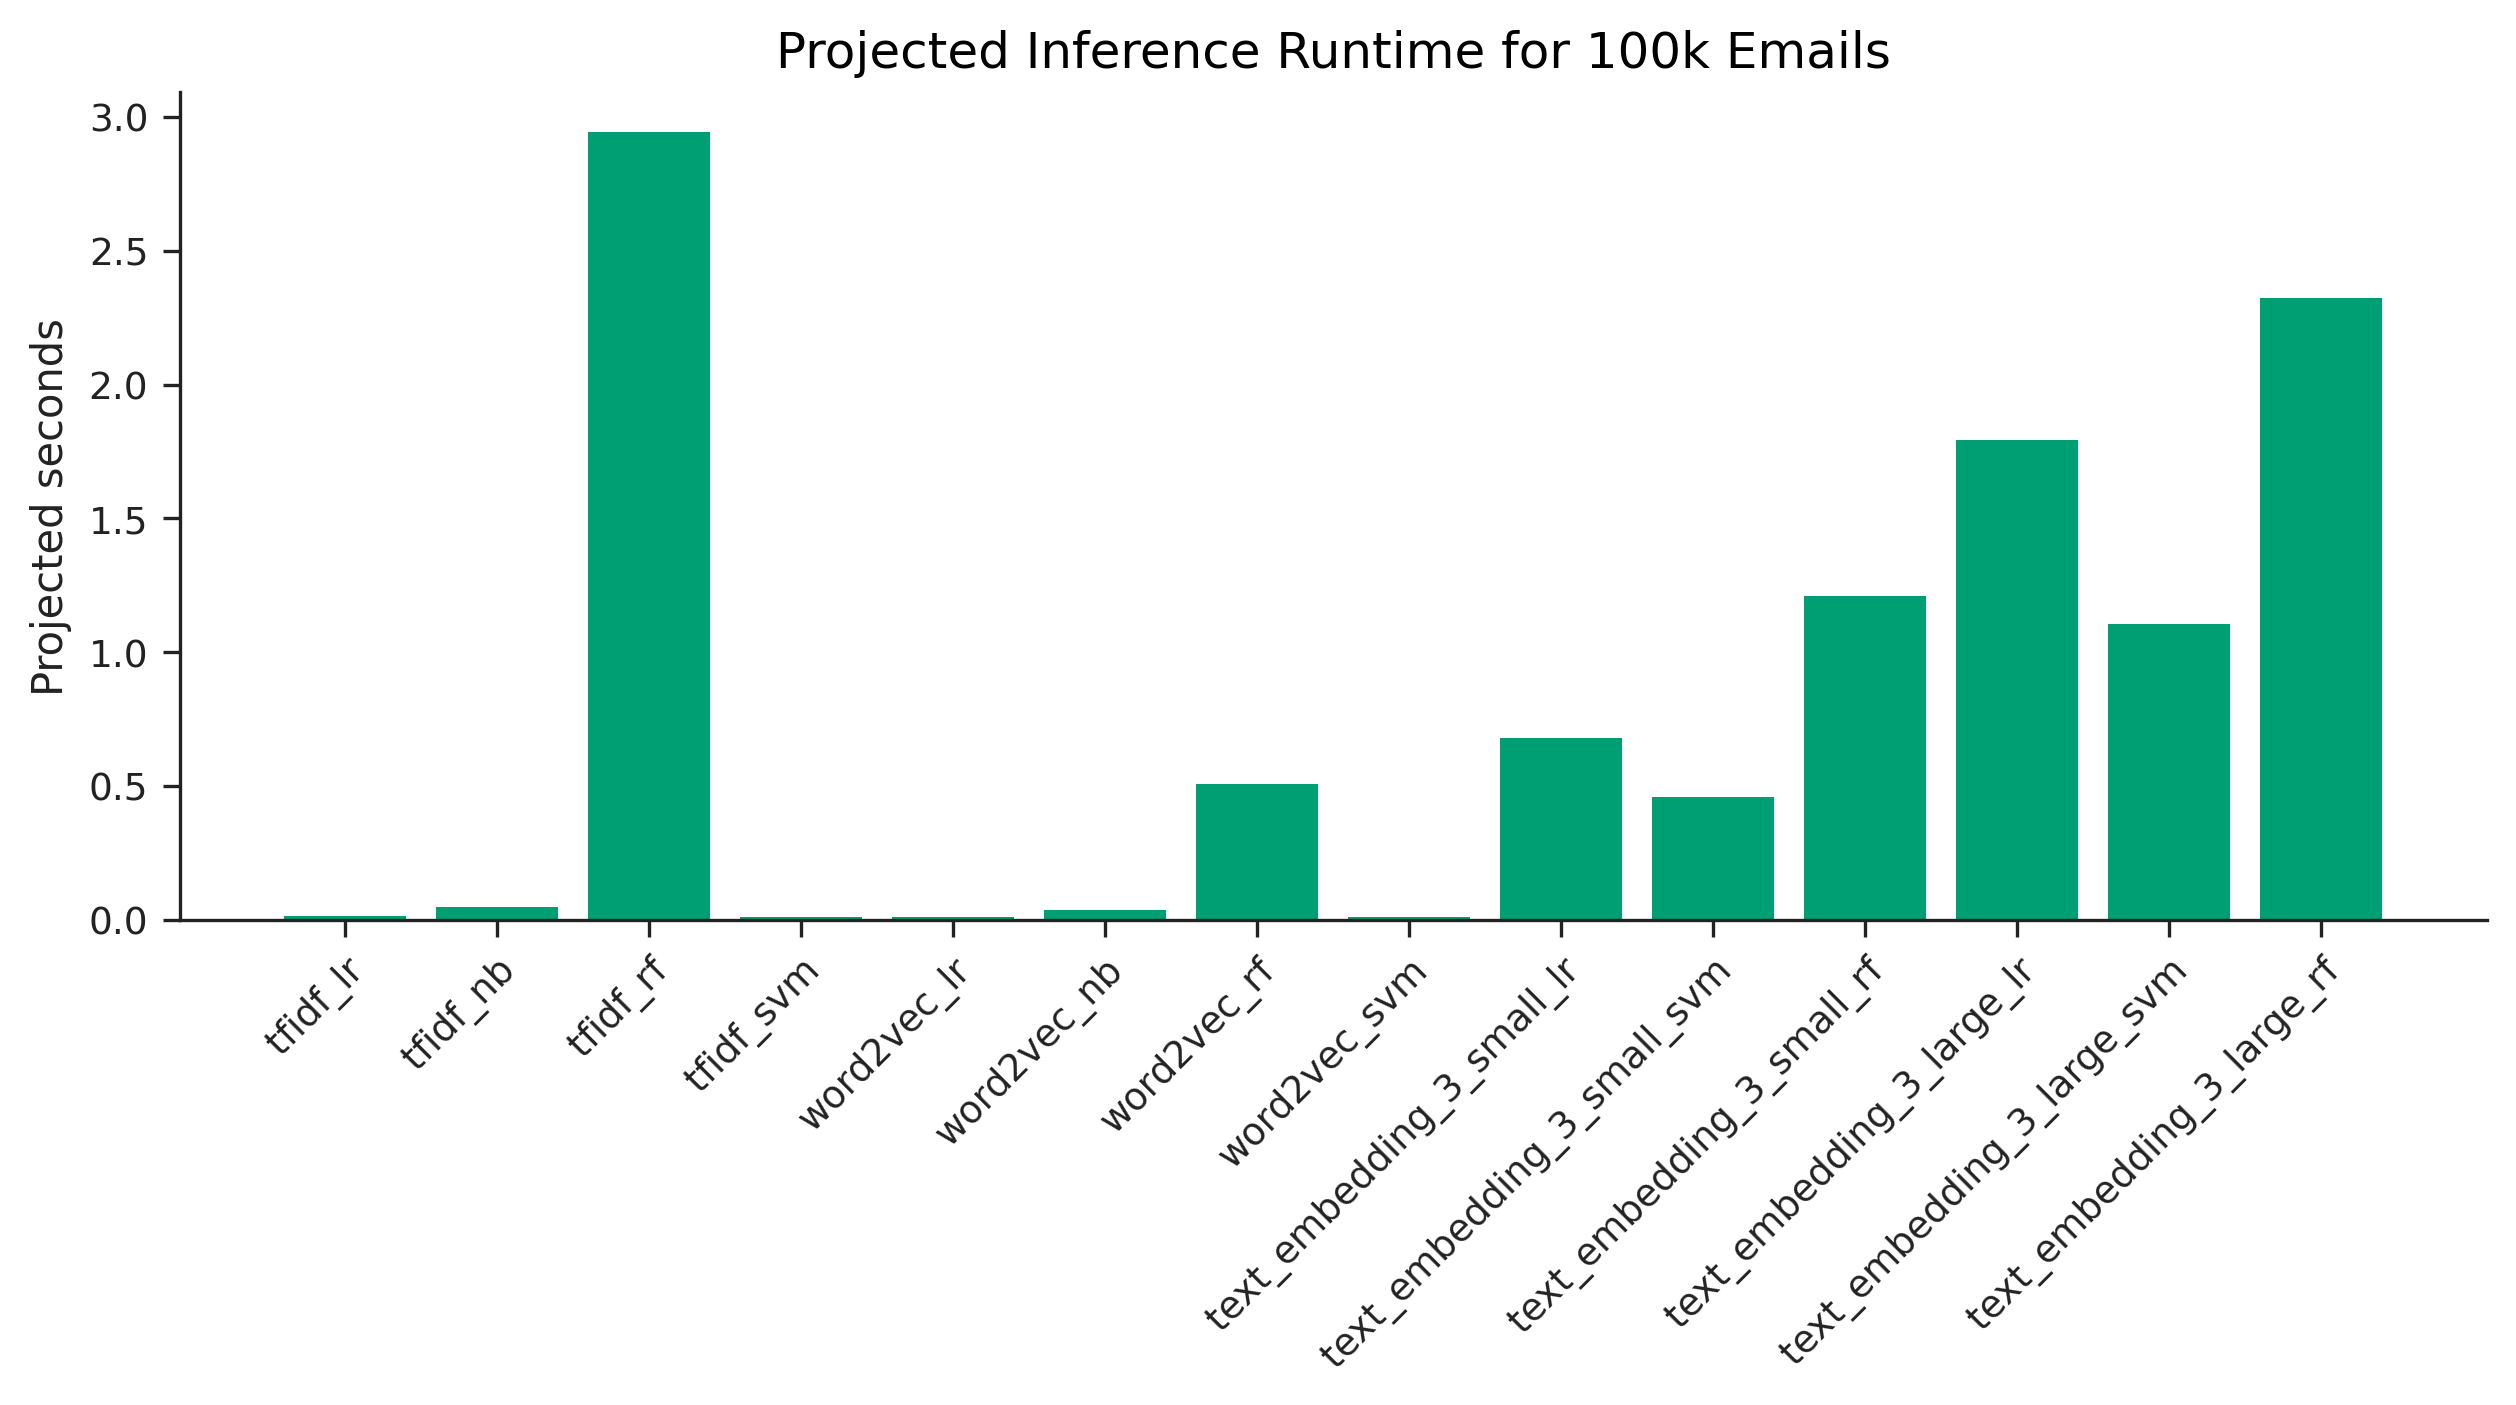

PNG preview: /Users/tiencains/Documents/dissertation/dissertation process/code/phishing_email_detection/output/figures/academic_projected_token_cost_100k.png


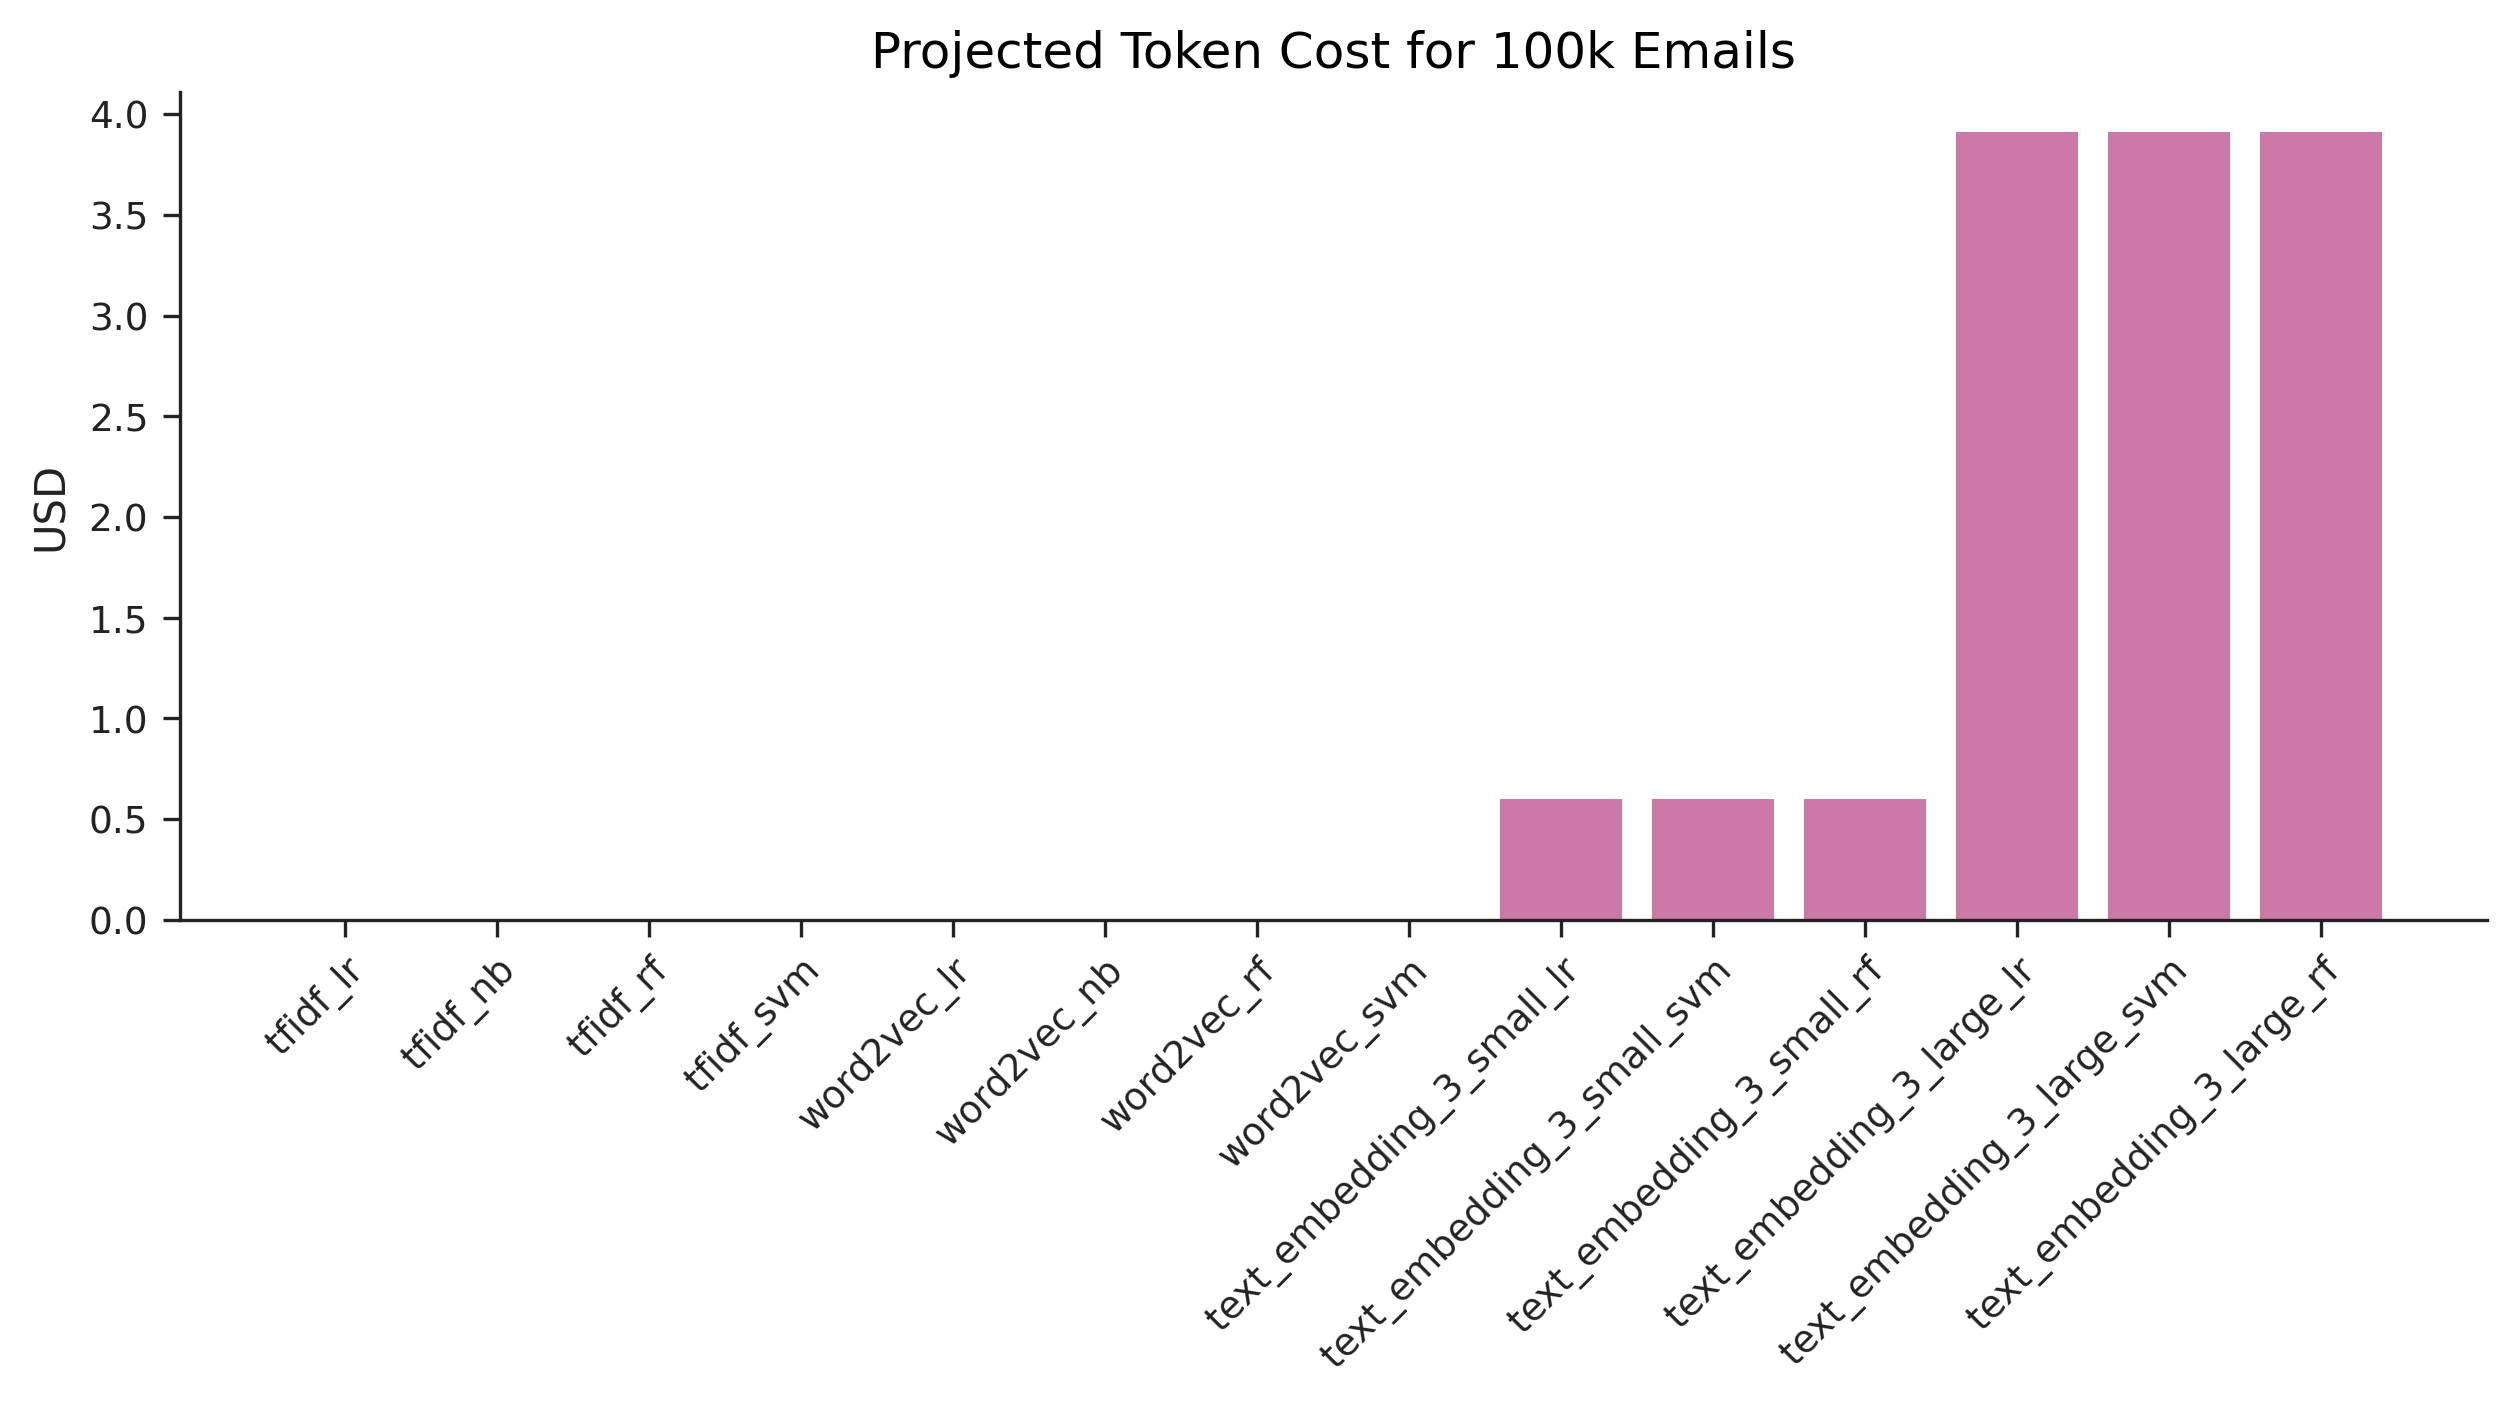

In [5]:
from IPython.display import Image, display


def show_csv_head(path, n=5):
    path = Path(path)
    print(f'CSV preview: {path}')
    if path.exists():
        try:
            display(pd.read_csv(path).head(n))
        except pd.errors.EmptyDataError:
            print('CSV exists but is empty because the optional stage was skipped.')
    else:
        print('Not found yet. Run the earlier cells first.')


def show_png(path):
    path = Path(path)
    print(f'PNG preview: {path}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Not found yet. Run the earlier cells first.')

show_csv_head(REPORT_OUTPUT_DIR / 'table_dataset_overview.csv')
show_csv_head(REPORT_OUTPUT_DIR / 'table_split_summary.csv')
show_png(FIGURE_OUTPUT_DIR / 'academic_model_performance_comparison.png')
show_png(FIGURE_OUTPUT_DIR / 'confusion_matrix_tfidf_nb.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_roc_tfidf.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_roc_word2vec.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_roc_openai_embeddings.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_roc_champion_comparison.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_fp_fn_comparison.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_robustness_degradation.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_projected_runtime_100k.png')
show_png(FIGURE_OUTPUT_DIR / 'academic_projected_token_cost_100k.png')
